In [1]:
import os
import sys
import glob
import pickle
import netCDF4 as nc
import wrf

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Circle
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib import rc
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature, BORDERS, ShapelyFeature, OCEAN, LAND
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.io.shapereader as shpreader
from shapely.geometry.polygon import Polygon
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle

import dill
import metpy.calc as mpcalc
from metpy.plots import SkewT
from metpy.units import units
import cmasher as cmr


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/wrf/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
"""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
##################################
Code used to plots all the Figures
##################################

Outputs: Figures 1 to 10.

The WRF data used to run Figs. 1.3, and Figs. 2 - 4 is not available in this repository due to storage constrains,
this data can be accessed upon request

The data used to run Figs. 5 - 10 is available in Thermals_comparison/results/

"""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""

'\n##################################\nCode used to plots all the Figures\n##################################\n\nOutputs: Figures 1 to 10.\n\nThe WRF data used to run Figs. 1.3, and Figs. 2 - 4 is not available in this repository due to storage constrains,\nthis data can be accessed upon request\n\nThe data used to run Figs. 5 - 10 is available in Thermals_comparison/results/\n\n'

In [3]:
path_fig = "/g/data/up6/ai2733/Thermals_comparison/figures/Figures"

In [4]:
def get_dirs(case, downdrafts):
    subdir = ""
    
    """
    Returns paths and file lists for d03 thermal tracking cases.

    Parameters:
        case (str): Case name, e.g., "CASE1" or "CASE2_new"
        downdrafts (bool): True for descending thermals, False for ascending thermals

    Returns:
        path_track (str): Base folder of tracking data
        path_grid (str): Folder where grids are saved
        dd_all (list): Sorted list of npy files for each thermal
        index_all (list): Index list corresponding to dd_all
        dd_all_entr (list): Sorted list of net entrainment files
    """

    # Determine folder prefix
    prefix  = "thermal_tracking" if downdrafts else "uw_thermal_tracking"
    prefix2 = "descending_thermals" if downdrafts else "ascending_thermals"

    # Handle CASE1 vs others
    base_case = case.lower() if case == "CASE1" else case.split("_new")[0].lower()

    # Paths
    path_track = f"/g/data/up6/ai2733/Thermals_comparison/thermal_tracking_code/{prefix2}/{prefix}_{base_case}_cropped/thermals_all/"
    path_grid  = f"/g/data/w28/ai2733/outputs_{case}_budgets/grid_tracking_cropped_new/{subdir}"

    # File patterns
    file_type = "downdraft_*" if downdrafts else "thermal_*"
    dd_all      = sorted(glob.glob(f"{path_track}/{file_type}/{file_type}_data.npy"))
    dd_all_entr = sorted(glob.glob(f"{path_track}/{file_type}/{file_type}_net_entr_term.npy"))

    index_all = list(range(len(dd_all)))

    return path_track, path_grid, dd_all, index_all, dd_all_entr

In [5]:
name_cases = {"CASE1": "Event 1", 
             "CASE2_new": "Event 2",
             "CASE3_new": "Event 3"}

min_t_all_cases = {"CASE1": 420,
                  "CASE2_new": 270,
                  "CASE3_new": 450}

init_t_all_cases = {"CASE1": "2015-12-16 07:00",
                  "CASE2_new": "2009-01-20 04:30",
                  "CASE3_new": "2017-02-17 07:30"}

## Read tracking data, WRF grid, and arrays

In [6]:
# Paths
path_arrays = "/g/data/up6/ai2733/Thermals_comparison/results/wrf_arrays/"
#path_arrays = "/results/wrf_arrays/"

path_results = "/g/data/up6/ai2733/Thermals_comparison/results/tracking_results/"
#path_results = "/results/tracking_results/"


In [7]:
# WRF domain and cases
dom = "d03"
cases = ["CASE1", "CASE2_new", "CASE3_new"]

In [8]:
# Tracking data
data_all_ = {}
for downdrafts in [True, False]:
    for case in cases: 
        key = f"{case}_{dom}_{'dd' if downdrafts else 'ud'}"
        with open(f'{path_results}/{key}.pkl', 'rb') as f:
            data_all_[key] = pickle.load(f)

In [9]:
# Subset of WRF data
downdrafts = True # Same for updrafts and downdrafts

# Most variables
wrf_all = {}
for case in cases:
    _, path_grid, _, _, _ = get_dirs(case, downdrafts)
    with open(f'{path_grid}/wrf_all.pkl', 'rb') as f: wrf_all[case] = dill.load(f)

# RAIN
wrf_rain = {}
for case in cases:
    _, path_grid, _, _, _ = get_dirs(case, downdrafts)
    with open(f'{path_grid}/wrf_all_rain.pkl', 'rb') as f: wrf_rain[case] = dill.load(f)

# Height
hgt_c = {}
for case in cases:
    _, path_grid, _, _, _ = get_dirs(case, downdrafts)
    with open(f'{path_grid}/data_grid.pkl', 'rb') as f: data_grid = dill.load(f)
    hgt_c[case] = data_grid["hgt_c"]

# Lat and Lon
lats_all, lons_all = {}, {}
for case in cases:
    lats_all[case] = np.array(wrf_all[case]["XLAT"].isel(Time = 0, west_east = 0))
    lons_all[case] = np.array(wrf_all[case]["XLONG"].isel(Time = 0, south_north = 0))

In [10]:
# Simulations times from 5-min outputs (not just tracking period)
times_cases = {}
for case in cases:
    times_cases[case] = np.load(f"{path_arrays}/Times_{case}.npy")

start_time_tracking = {"CASE1":83,
                      "CASE2_new":53,
                      "CASE3_new":89}

for case in cases: print (case, times_cases[case][start_time_tracking[case]])

CASE1 2015-12-16T07:00:00.000000000
CASE2_new 2009-01-20T04:30:00.000000000
CASE3_new 2017-02-17T07:30:00.000000000


In [11]:
# For Soundings/CAPE calculation, spatial-averaged profiles
tk_mean, p_mean, td_mean = {}, {}, {}
for case in cases:
    tk_mean[case] = np.load(f"{path_arrays}/TimeProf_{case}_{dom}_tk_80kmAWS_coarsen.npy")
    p_mean[case]  = np.load(f"{path_arrays}/TimeProf_{case}_{dom}_pressure_80kmAWS_coarsen.npy")
    td_mean[case] = np.load(f"{path_arrays}/TimeProf_{case}_{dom}_td_80kmAWS_coarsen.npy")

## Figure 1.1: Map with domains

In [9]:
# Plot WRF domains
path_domains = "/g/data/up6/ai2733/Thermals_comparison/results/wps_domains/"
#path_domains = "/results/wps_domains/"

color_cases = {"CASE1":"k", 
              "CASE2_new": "blue", 
              "CASE3_new":"crimson"}

name_cases_maps    = {"CASE1": "Event 1: Moree",
                 "CASE2_new": "Event 2 : Wagga Wagga", 
                 "CASE3_new": "Event 3: Tamworth"}

lat_lon_cases = {"CASE1": (-29.49, 149.85), 
                "CASE2_new": (-35.16, 147.46), 
                 "CASE3_new": (-31.07,150.84)}


In [10]:
# Read WRF domains
with open(f'{path_domains}/extent_d3.pkl', 'rb') as f:
    extent_d3 = pickle.load(f)

with open(f'{path_domains}/extent_d2.pkl', 'rb') as f:
    extent_d2 = pickle.load(f)

with open(f'{path_domains}/extent_d1.pkl', 'rb') as f:
    extent_d1 = pickle.load(f)

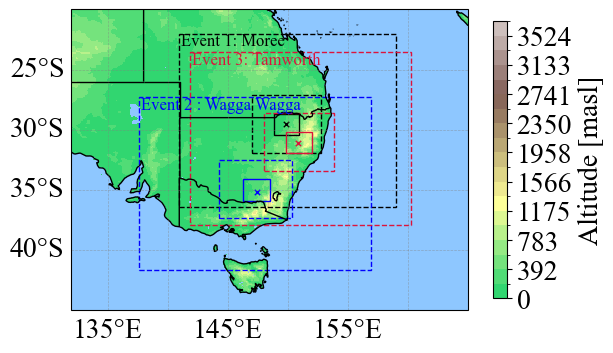

In [14]:
fs = 20
plt.rcParams.update({
    "font.size": fs,            # Controls most text: tick labels, axis labels, legend, etc.
    "axes.titlesize": fs,       # Title size for subplots
    "axes.labelsize": fs,       # Axis label size
    "xtick.labelsize": fs,      # X tick label size
    "ytick.labelsize": fs,      # Y tick label size
    "legend.fontsize": fs,      # Legend font size
    "figure.titlesize": fs,     # Figure-wide title size (if you use `fig.suptitle`),
     "font.family": "Times New Roman",
})

# Read topography, with land mask : at 10 km 
topo = xr.open_dataset(f"{path_domains}/topo.nc")["HGT"]

cmap_terr = cmr.get_sub_cmap(cmr.apple_r, 0.3, 1.0)
cmap_terr = cmr.get_sub_cmap("terrain", 0.3, 0.9)
cmap_terr.set_bad('dodgerblue',0.5)

# Create a figure and axis with a specific projection
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the data using xarray's built-in plot function
im = topo.plot(ax=ax, cmap=cmap_terr, transform=ccrs.PlateCarree(), levels = 20, robust = False, add_colorbar = False, vmin = 0) #, extend='both')
cbar = plt.colorbar(im, ax=ax,orientation='vertical', shrink=0.75, label = "Altitude [masl]") #, extend = "max")
# Customize the plot with Cartopy features (e.g., coastlines, borders, and gridlines)
ax.coastlines()
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'minor_islands', scale='10m', edgecolor='k'), lw = 1.0)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False  # Hide labels on the upper side
gl.right_labels = False  # Hide labels on the left side

# Australian states
states_provinces = NaturalEarthFeature(category = 'cultural',name  = 'admin_1_states_provinces_lines',scale = '50m',facecolor='none')
ax.add_feature(states_provinces, edgecolor='black')

for case in cases:
    lon1_d3, lon2_d3, lat1_d3, lat2_d3 = extent_d3[case]
    rectangle_d3 = Rectangle((lon1_d3, lat1_d3), lon2_d3 - lon1_d3, lat2_d3 - lat1_d3, linewidth=1.0, edgecolor=color_cases[case], facecolor='none', transform=ccrs.PlateCarree())

    lon1_d2, lon2_d2, lat1_d2, lat2_d2 = extent_d2[case]
    rectangle_d2 = Rectangle((lon1_d2, lat1_d2), lon2_d2 - lon1_d2, lat2_d2 - lat1_d2, linewidth=1.0, ls = "--", edgecolor=color_cases[case], facecolor='none', transform=ccrs.PlateCarree())

    lon1_d1, lon2_d1, lat1_d1, lat2_d1 = extent_d1[case]
    rectangle_d1 = Rectangle((lon1_d1, lat1_d1), lon2_d1 - lon1_d1, lat2_d1 - lat1_d1, linewidth=1.0, ls = "--", edgecolor=color_cases[case], facecolor='none', transform=ccrs.PlateCarree())
    
    ax.add_patch(rectangle_d3)
    ax.add_patch(rectangle_d2)
    ax.add_patch(rectangle_d1)
    
    text_x = lon1_d1 + 0.2  # small offset to the right
    text_y = lat2_d1 - 1.  # small offset down from top edge
    ax.text(text_x, text_y, name_cases_maps[case], fontsize=12,
            color=color_cases[case], transform=ccrs.PlateCarree(),
            bbox=dict(facecolor='white', alpha=0.0, edgecolor='none', boxstyle='round,pad=0.2'))
    
    # Add BOM stations
    scatter1 = ax.scatter(lat_lon_cases[case][1],lat_lon_cases[case][0], marker = "x", facecolor = color_cases[case], linewidths = 1.0, s = 15., transform=ccrs.PlateCarree())

# Show the plot
ax.set_extent([132., 165., -45., -20.], crs=ccrs.PlateCarree())
plt.savefig(f"{path_fig}/Figure1_1.png", dpi=500, bbox_inches="tight")
plt.show()

## Figure 1.2: Domain-average variables

In [15]:
color_cases = {"CASE1":"k", 
              "CASE2_new": "blue", 
              "CASE3_new":"crimson"}

label_vars = {
   "tk": "Temperature",
    "rh": "Relative humidity", 
    "REFL_10CM": "Col. max reflectivity", 
    "MSE": "Moist Static Energy", 
    "RAINNC": "Accumulated precipitation", 
    "CAPE":"Surface-based CAPE"
}
units_vars = {
   "tk": "[C]",
    "rh": "[%]", 
    "REFL_10CM": "[dbZ]", 
    "MSE": "[kJ/kg]", 
    "QRAIN": "[g/kg]", 
    "RAINNC": "[mm]", 
    "CAPE": "J/kg"
}

titles = [ "Reflectivity / Precipitation", 
           "Temperature", 
           "Relative humidity",
           "MSE "]

axis_labels = ["Reflectivity [dbZ]",
               "Precipitation [mm]",
               "Near-surface [C]", 
               "(0-3 km) [C]",
                "Near-surface [%]", 
               "(0-3 km) [%]",
               "MSE [kJ/kg]"]#, 
               #"CAPE [J/kg]"]

axis_lims = [[0,40],
             [0,7],
             [0,36],
             [0,36], 
             [0,80],
             [0,80],
             [310, 340]            
]

In [16]:
# Get variables to plot
vars_to_plot = {}
for case in cases:
    vars_to_plot[case] = []
    # Col-max refl
    vars_to_plot[case].append(wrf_all[case]["REFL_10CM"].max("z").mean(["south_north", "west_east"]))
    # Accum prec
    rain_aux = wrf_rain[case]["RAINNC"] # Accumulated
    rain_aux = rain_aux.mean(["west_east", "south_north"]) # Mean accum
    da = np.array(rain_aux)
    if case == "CASE3_new":
        rain_aux[30] = np.NaN # sporious because of restart
        da = pd.Series(rain_aux).interpolate(method="linear", limit_direction="both").to_numpy()     
    vars_to_plot[case].append(da)
    # First-level and 0-3km average Temp
    pos_height = np.where(hgt_c[case]<=3000.)[0]
    vars_to_plot[case].append(wrf_all[case]["tk"].isel(z=0).mean(["south_north", "west_east"])-273.15)
    vars_to_plot[case].append(wrf_all[case]["tk"].isel(z = pos_height).mean(["z", "south_north", "west_east"])-273.15)
    # First-level and 0-3km average HR
    vars_to_plot[case].append(wrf_all[case]["rh"].isel(z=0).mean(["south_north", "west_east"]))
    vars_to_plot[case].append(wrf_all[case]["rh"].isel(z = pos_height).mean(["z", "south_north", "west_east"]))

# Mean values
refl_mean = np.array([vars_to_plot[case][0].mean().item() for case in cases])
prec_mean = np.array([vars_to_plot[case][1].mean().item() for case in cases])

temp_mean_surf   = np.array([vars_to_plot[case][2].mean().item() for case in cases])
temp_mean_layer  = np.array([vars_to_plot[case][3].mean().item() for case in cases])

hr_mean_surf  = np.array([vars_to_plot[case][4].mean().item() for case in cases])
hr_mean_layer  = np.array([vars_to_plot[case][5].mean().item() for case in cases])


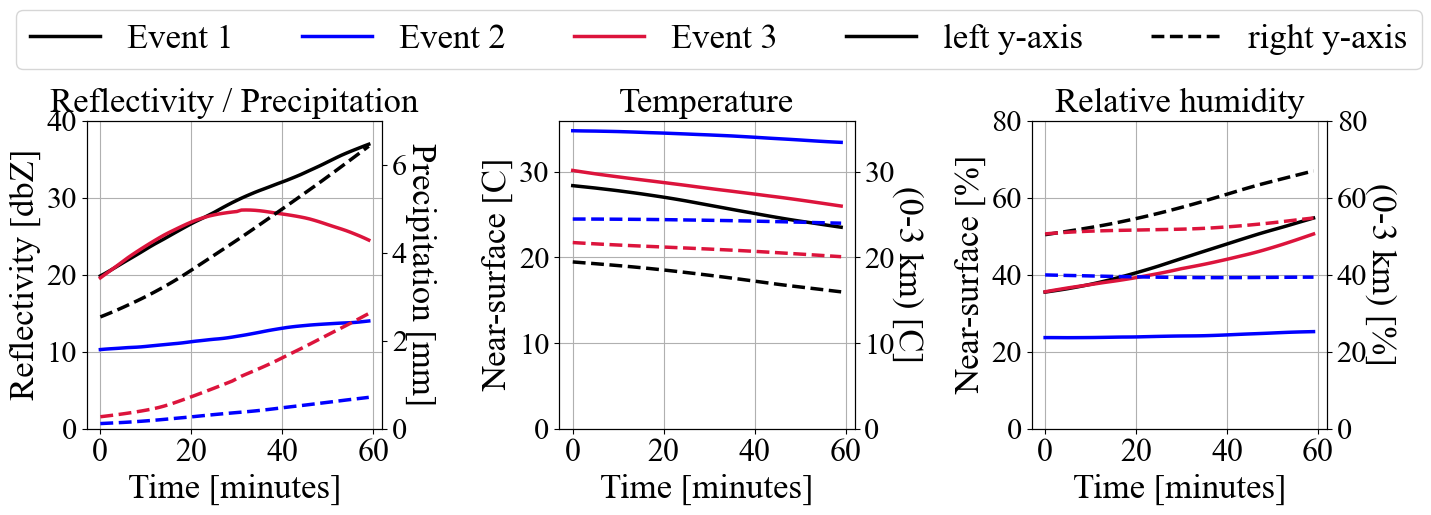

In [17]:
fs = 25
plt.rcParams.update({
    "font.size": fs,            # Controls most text: tick labels, axis labels, legend, etc.
    "axes.titlesize": fs,       # Title size for subplots
    "axes.labelsize": fs,       # Axis label size
    "xtick.labelsize": fs-2,      # X tick label size
    "ytick.labelsize": fs-3,      # Y tick label size
    "legend.fontsize": fs,      # Legend font size
    "figure.titlesize": fs,     # Figure-wide title size (if you use `fig.suptitle`),
     "font.family": "Times New Roman",
})


fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    left_var_index = 2*i       
    right_var_index = 2*i + 1  

    if i < 3:
        ax2 = ax.twinx()
    for case in cases:
        # Plot left y-axis variable
        ax.plot(vars_to_plot[case][left_var_index], 
                label=f'{name_cases[case]}', 
                color=color_cases[case], lw=2.5)
        ax.set_ylabel(axis_labels[left_var_index])
        ax.set_ylim(axis_lims[left_var_index][0], axis_lims[left_var_index][1])
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5)) 

        try:
            # Plot right y-axis variable
            ax2.plot(vars_to_plot[case][right_var_index], 
                     label=f'{name_cases[case]}', 
                     color=color_cases[case], lw=2.5, ls='--')
            ax2.set_ylabel(axis_labels[right_var_index], rotation=270, labelpad=21)
            ax2.set_ylim(axis_lims[right_var_index][0], axis_lims[right_var_index][1])
        except:
            pass

    ax.yaxis.set_major_locator(MaxNLocator(nbins=4)) 
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4)) 

    if i < 3:
        ax2.xaxis.set_major_locator(MaxNLocator(nbins=4)) 
        ax2.yaxis.set_major_locator(MaxNLocator(nbins=4)) 

    ax.set_title(titles[i])
    ax.grid(True)
    
# Common x-label
for ax in axes:
    ax.set_xlabel("Time [minutes]")

handles, labels = axes[0].get_legend_handles_labels()

style_handles = [
    Line2D([0], [0], color='k', lw=2.5, ls='-'),
    Line2D([0], [0], color='k', lw=2.5, ls='--')
]
style_labels = ['left y-axis', 'right y-axis']
fig.legend(
    handles + style_handles,
    labels + style_labels,
    loc="upper center",
    bbox_to_anchor=(0.07, 1.15, 0.9, 0.05),  # left, bottom, width, height (0–1 relative to figure)
    bbox_transform=fig.transFigure,
    ncol=len(handles) + 2,  # adjust number of columns
    mode="expand",            # make legend span the full width
    frameon=True
)

fig.subplots_adjust(hspace=0.3, wspace = 0.6)
plt.savefig(f"{path_fig}/Figure1_2.png", dpi=500, bbox_inches="tight")
plt.show()


## Figure 1.3: Soundings

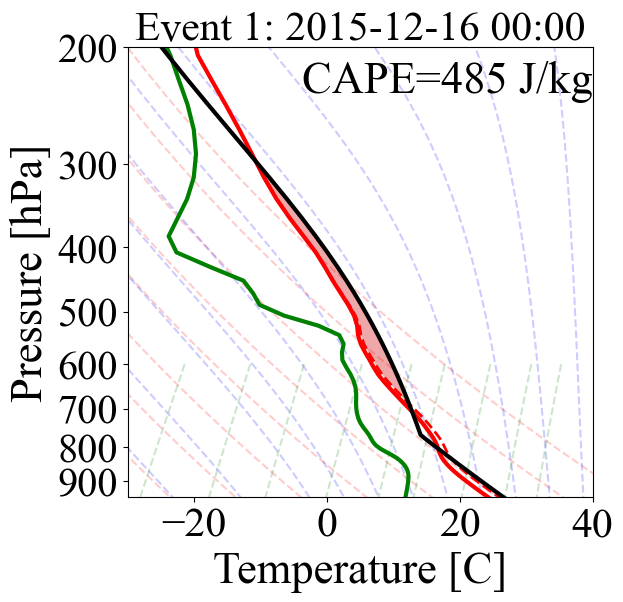

<Figure size 640x480 with 0 Axes>

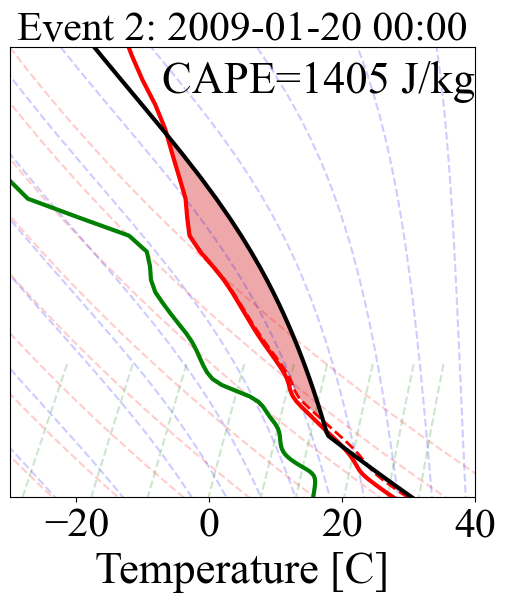

<Figure size 640x480 with 0 Axes>

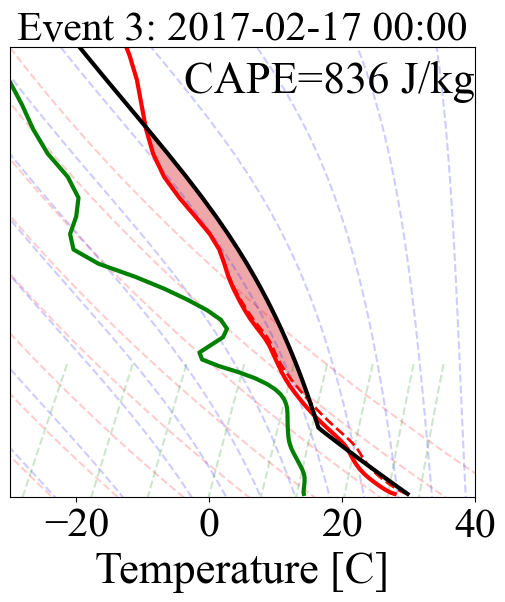

<Figure size 640x480 with 0 Axes>

In [18]:
# SKEW-T at certain time (t = 0)
fs = 32
plt.rcParams.update({
    "font.size": fs,            # Controls most text: tick labels, axis labels, legend, etc.
    "axes.titlesize": fs-2,       # Title size for subplots
    "axes.labelsize": fs,       # Axis label size
    "xtick.labelsize": fs-2,      # X tick label size
    "ytick.labelsize": fs-3,      # Y tick label size
    "legend.fontsize": fs,      # Legend font size
    "figure.titlesize": fs,     # Figure-wide title size (if you use `fig.suptitle`),
     "font.family": "Times New Roman",
})

# Select time index
t = 0 
cape_all = {}
for i, case in enumerate(cases):

    cape_all[case] = []


    tk_prof = tk_mean[case][t, :]
    p_prof  = p_mean[case][t, :]
    td_prof = td_mean[case][t, :]

    # Attach units
    temperature = (tk_prof * units.kelvin).to('degC')
    pressure    = (p_prof * units.hPa).to('hPa')
    dewpoint    = (td_prof * units.degC).to('degC')

    vtemperature = mpcalc.virtual_temperature_from_dewpoint(pressure, temperature, dewpoint)
                                      
    # Create subplot axis
    fig = plt.figure(figsize=(6, 9))
    skew = SkewT(fig)
    skew.ax.set_aspect(100)  # smaller → taller, larger → squished

    # Plot sounding
    skew.plot(pressure, temperature, 'r', linewidth = 3.0)
    skew.plot(pressure, vtemperature, 'r', linewidth = 2.0, ls = "--")

    skew.plot(pressure, dewpoint, 'g', linewidth = 3.0)

    # Parcel + CAPE
    parcel_profile = mpcalc.parcel_profile(
        pressure, vtemperature[0], dewpoint[0]
    ).to('degC')

    cape, cin = mpcalc.cape_cin(
        pressure, vtemperature, dewpoint, parcel_profile
    )

    cape_all[case].append(cape)

    skew.plot(pressure, parcel_profile, 'k', linewidth=3.0)
    skew.shade_cape(pressure, vtemperature, parcel_profile)

    # Background
    skew.plot_dry_adiabats(alpha=0.2)
    skew.plot_moist_adiabats(alpha=0.2)
    skew.plot_mixing_lines(alpha=0.2)

    skew.ax.set_ylim(950, 200)
    skew.ax.set_xlim(-30, 40)
    skew.ax.set_ylabel("Pressure [hPa]")
    skew.ax.set_xlabel("Temperature [C]")

    if i > 0:
        skew.ax.set_ylabel('')
        skew.ax.tick_params(axis='y', which='both', left=False, labelleft=False)

    skew.ax.grid(False)

    title_ = f"{name_cases[case]}: {str(times_cases[case][0])[:16].replace('T00:05',' 00:00')}"
    skew.ax.set_title(title_)

    skew.ax.xaxis.set_major_locator(MaxNLocator(nbins=7))
    skew.ax.text(
    1.0, 0.97,  # coordinates in axes fraction (x=1.0,y=1.0 is top-right)
    f"CAPE={cape.m:.0f} J/kg",
    transform=skew.ax.transAxes,  # use axes coordinates (0..1)
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor='none', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.3')
)
    plt.show()
    plt.savefig(f"{path_fig}/Figure1_3_{case}.png", dpi=500, bbox_inches="tight")


## Figure 2: Maps

In [19]:
def get_thermals(case, downdraft, idx_time):
    """""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
    Function to get thermals at certain time
    """""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
    
    key = f"{case}_{dom}_{'dd' if downdraft else 'ud'}"
    # Extract data
    (
                    x_centre, y_centre, z_centre,wmax_c, W_c, time_c, R_c, z_centre_c,mass_c, path_case, N_t, t_range, R_mean, W_mean, R_std, R_10, R_90, W_std, W_10, W_90,
        acc_mean, Fres_mean, Fnh_mean, buoy_mean, acc_10, acc_90,
        Fres_10, Fres_90, Fnh_10, Fnh_90, buoy_10, buoy_90,
        t_range2, net_entr_term_mean, net_entr_term_std,
        Z, R_avg, W_avg, net_entr_avg, Z2, net_entr_l, net_entr_r,
        acc_avg, Fnh_avg, Fres_avg, buoy_avg, Fentr_avg,
        ix_left, ix_right, bins_x, weights_x,
        iz_up, iz_low, bins_z, weights_z,
        acc_c, Fres_c, buoy_c, fnh_c, fmix_c, r_c, r_c_mean, r_c_std,
        acc_c_mean, Fres_c_mean, buoy_c_mean, fnh_c_mean, fmix_c_mean,
        acc_c_std, Fres_c_std, buoy_c_std, fnh_c_std, fmix_c_std,
        N_avg, lifetime_avg, wmax_avg, massflux_avg,
        x_new, y_new, z_new, w_dev_grossmean, u_dev_grossmean, v_dev_grossmean,
                    rh_grossmean, qvapor_grossmean, qrain_grossmean, qcloud_grossmean, qicesnow_grossmean, qghail_grossmean, buoy_mean_t, detrainment_grossmean, entrainment_grossmean, latheat_grossmean, qghail_c, qcloud_c, qicesnow_c, qrain_c

    ) = data_all_[key]

    min_t_all = min_t_all_cases[case]
    time_c_idx = time_c-min_t_all # Times in index: in float

    thermals_filt2, idx_filt, x_pos, y_pos, z_pos = [], [], [], [], []
    for idx_thermal, times_thermal in enumerate(time_c_idx):
        if idx_time in times_thermal:
            idx_time2 = list(time_c_idx[idx_thermal]).index(idx_time)
            thermals_filt2.append(idx_thermal)
            idx_filt.append(idx_time2)
            x_pos.append(x_centre[idx_thermal][idx_time2])
            y_pos.append(y_centre[idx_thermal][idx_time2])
            z_pos.append(z_centre[idx_thermal][idx_time2])
            
    return thermals_filt2, idx_filt, x_pos, y_pos, z_pos

In [20]:
label_vars = {
   "tk": "Near-surface\n temperature ",
    "rh": "Near-surface \nrelative humidity ", 
    "REFL_10CM": "Column-maximum\nreflectivity ", 
    "MSE": "Near-surface Moist \nStatic Energy ", 
    "wa_up": "Column-maximum upward \nvertical velocity ", 
    "wa_down": "Column-minimum downward \nvertical velocity ", 
    "QRAIN": "Column-total rainwater\n mixing ratio ",
    
}
units_vars = {
   "tk": "[C]",
    "rh": "[%]", 
    "REFL_10CM": "[dbZ]", 
    "MSE": "[kJ/kg]", 
    "wa_up": "[m/s]", 
    "wa_down": "[m/s]",
    "QRAIN": "[kg/kg]"
}

name_labels = {"CASE1": "Event 1\nLatitude [°N]", 
             "CASE2_new": "Event 2\nLatitude [°N]",
             "CASE3_new": "Event 3\nLatitude [°N]"}

In [21]:
def plot_maps_time(var_list, cmap_list, time_to_plot, name_fig):
    """""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
    Function to plot the spatial maps of certain variables at certain time
    """""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
    
    plt.close("all")

    fs = 22
    plt.rcParams.update({
        "font.size": fs,            # Controls most text: tick labels, axis labels, legend, etc.
        "axes.titlesize": fs,       # Title size for subplots
        "axes.labelsize": fs,       # Axis label size
        "xtick.labelsize": fs-2,      # X tick label size
        "ytick.labelsize": fs-2,      # Y tick label size
        "legend.fontsize": fs-2,      # Legend font size
        "figure.titlesize": fs-2,     # Figure-wide title size (if you use `fig.suptitle`),
         "font.family": "Times New Roman",
    })

    nrows = len(cases)
    ncols = len(var_list)

    # vertical level (if needed)
    idx_levels = {case: 0 for case in cases}

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4.5 * ncols, 4 * nrows),
        constrained_layout=False
    )

    if nrows == 1:
        axes = axes[np.newaxis, :]
    if ncols == 1:
        axes = axes[:, np.newaxis]

    # =========================
    # LOOP OVER VARIABLES (COLUMNS)
    # =========================
    for col_i, (var, cmap_) in enumerate(zip(var_list, cmap_list)):

        # ---- compute vmin/vmax for this variable ----
        all_data = []

        for case in cases:
            if var == "REFL_10CM":           # column max
                da = wrf_all[case][var].isel(Time=time_to_plot).max("z")
            elif var == "QRAIN":             # column sum
                da = wrf_all[case][var].isel(Time=time_to_plot).sum("z")
            elif var == "wa_up":             # column max (>0)
                da = wrf_all[case]["wa"].isel(Time=time_to_plot)
                da = xr.where(da > 0, da, np.nan).max("z")
            elif var == "wa_down":           # column min (<0)
                da = wrf_all[case]["wa"].isel(Time=time_to_plot)
                da = xr.where(da < 0, da, np.nan).min("z")
            else:                            # single level
                da = wrf_all[case][var].isel(
                    Time=time_to_plot, z=idx_levels[case]
                )
            
            if var == "tk":
                da = da - 273.15
        
            all_data.append(da.values)

        all_data = np.concatenate(all_data)
        vmin, vmax = np.nanmin(all_data), np.nanmax(all_data)
        del all_data

        # =========================
        # LOOP OVER CASES (ROWS)
        # =========================
        for row_i, case in enumerate(cases):

            if var == "REFL_10CM":
                da = wrf_all[case][var].isel(Time=time_to_plot).max("z")
            elif var == "QRAIN":
                da = wrf_all[case][var].isel(Time=time_to_plot).sum("z")
            elif var == "wa_up":
                da = wrf_all[case]["wa"].isel(Time=time_to_plot)
                da = xr.where(da > 0, da, np.nan).max("z")
            elif var == "wa_down":
                da = wrf_all[case]["wa"].isel(Time=time_to_plot)
                da = xr.where(da < 0, da, np.nan).min("z")
            else:
                da = wrf_all[case][var].isel(
                    Time=time_to_plot, z=idx_levels[case]
                )

            if var == "tk":
                da = da - 273.15

            da = da.assign_coords(
                west_east=lons_all[case],
                south_north=lats_all[case]
            )

            ax = axes[row_i, col_i]

            nlev = 16
            levels = np.linspace(vmin, vmax, nlev)

            im = da.plot(
                x="west_east",
                y="south_north",
                ax=ax,
                cmap=cmap_,
                levels=levels,
                add_colorbar=False
            )

            # ---- titles & labels ----
            #if row_i == 0:
            #    ax.set_title(var)
            #else:
            ax.set_title("")

            if col_i == 0:
                ax.set_ylabel(name_cases[case])
            else:
                ax.set_ylabel("")
                ax.set_yticks([])

            #if row_i != 2:
            #    axes[row_i, col_i].set_xticks([])

            ax.set_xlabel("")

            # ---- plot thermals ----
            for downdraft in [True, False]:
                _, _, x_pos, y_pos, _ = get_thermals(case, downdraft, time_to_plot)

                x_pos_long = [lons_all[case][int(i)] for i in x_pos]
                y_pos_lat  = [lats_all[case][int(i)] for i in y_pos]

                ax.scatter(
                    x_pos_long,
                    y_pos_lat,
                    marker="v" if downdraft else "^",
                    color="blue" if downdraft else "red",
                    edgecolors="white",
                    linewidths=1.2,
                    zorder=10
                )

            # Transect
            if col_i == 0:    

                axes[row_i, col_i].set_ylabel(name_labels[case])
                
                # Plot the transect in (x,y) plane
                ax.plot([lons_all[case][0], lons_all[case][-1]], [lats_all[case][0], lats_all[case][-1]],
                        lw = 2.0, ls = "--", color='white' if row_i == 0 else 'black')

            if row_i == 2:
                axes[row_i, col_i].set_xlabel("Longitude [°E]")
                
        # =========================
        # COLORBAR (ONE PER VARIABLE, BOTTOM)
        # =========================
        cax = fig.add_axes([
            axes[0, col_i].get_position().x0,
            axes[0, col_i].get_position().y1 + 0.04,
            axes[0, col_i].get_position().width,
            0.02
        ])

        cbar = fig.colorbar(im, cax=cax, orientation="horizontal", pad = 0.5)
        cbar.set_label(label_vars[var] + " " + units_vars[var])
        cbar.ax.xaxis.set_label_position("top")

        cbar.locator = MaxNLocator(nbins=5, prune="both")
        cbar.update_ticks()

    for i, label in enumerate(["a)", "b)", "c)"]):
        axes[i, 0].text(
            -0.45, 1.05, label,
            transform=axes[i, 0].transAxes,
            fontsize=22, fontweight="bold",
            va="top", ha="left"
        )

    plt.savefig(f"{path_fig}/Figure2.png", dpi=500, bbox_inches="tight")
    plt.show()


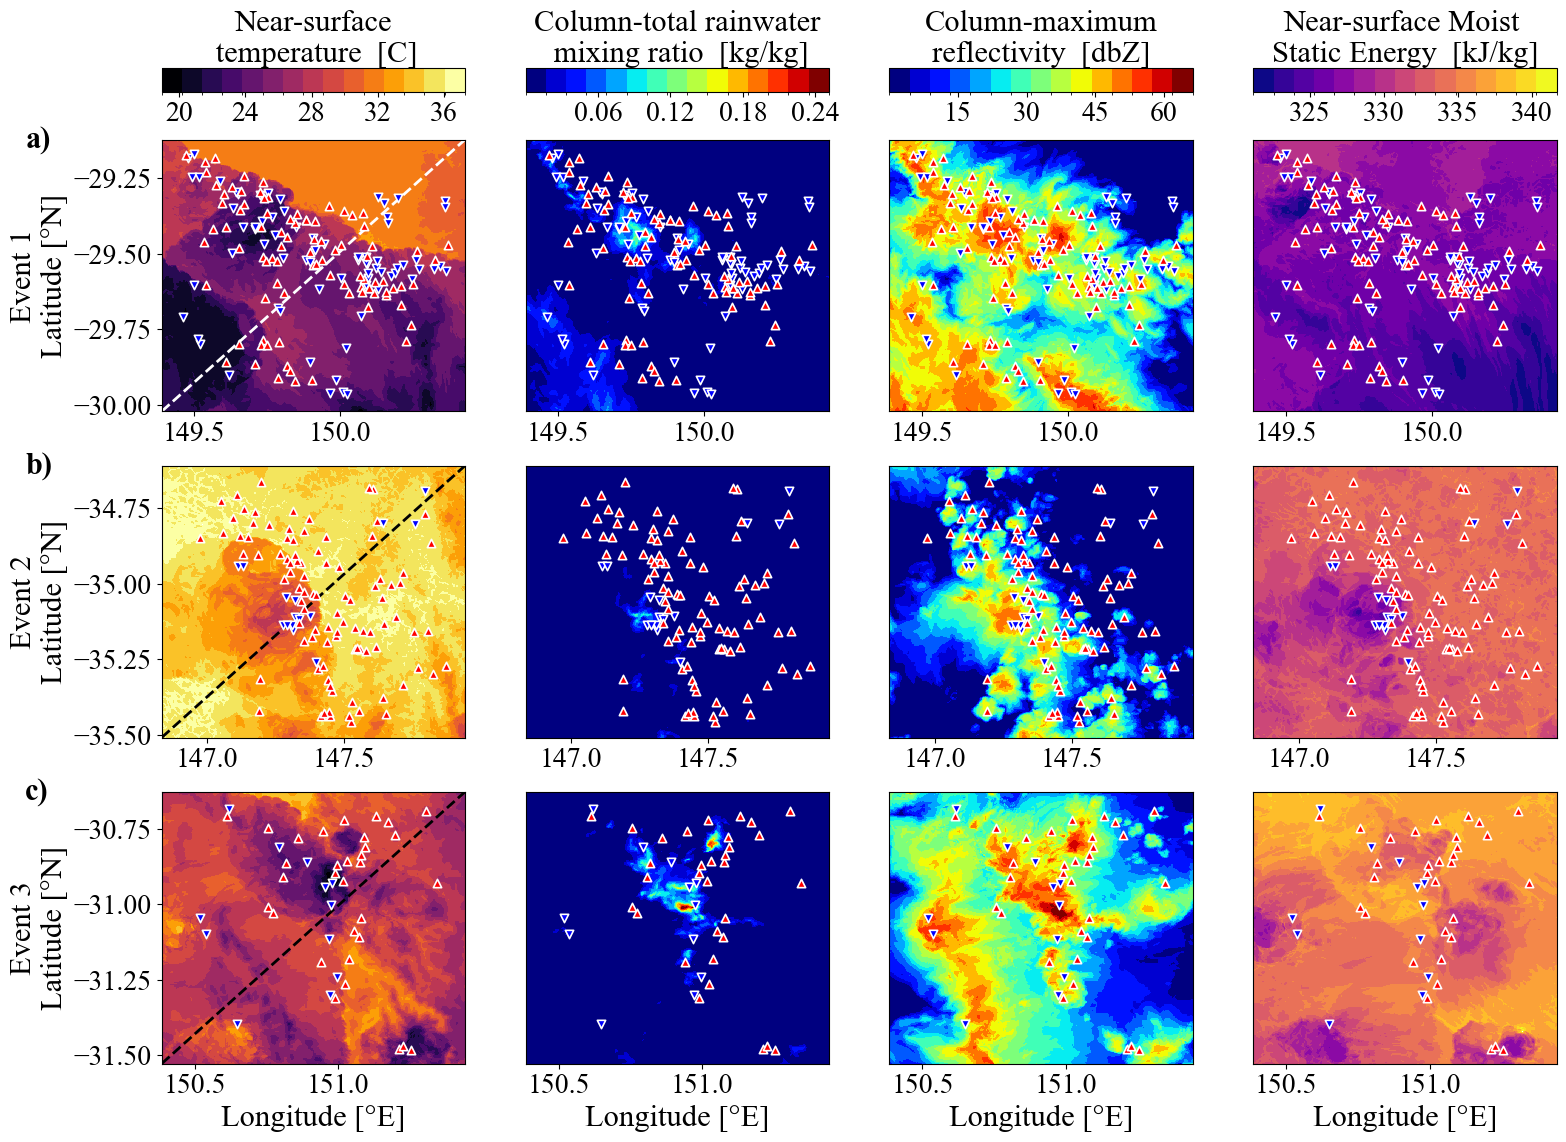

In [22]:
plot_maps_time(var_list = ["tk", "QRAIN", "REFL_10CM", "MSE"],
               cmap_list = ["inferno", "jet", "jet", "plasma"], 
               time_to_plot = 30, name_fig = "Figure2")

## Figure 3: Cross sections

In [23]:
def plot_cross_section_one(max_height, case, var_, label_var, idx, thermals = False,
                           cmap_ = "jet", n_levels = 20, buffer = 10, lims = []):

    """""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
    Function to plot cross sections of certain variable at certain time, up to a certain height
    """""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""

    fs = 24
    plt.rcParams.update({
        "font.size": fs,            # Controls most text: tick labels, axis labels, legend, etc.
        "axes.titlesize": fs,       # Title size for subplots
        "axes.labelsize": fs,       # Axis label size
        "xtick.labelsize": fs-2,      # X tick label size
        "ytick.labelsize": fs-2,      # Y tick label size
        "legend.fontsize": fs-2,      # Legend font size
        "figure.titlesize": fs-2,     # Figure-wide title size (if you use `fig.suptitle`),
         "font.family": "Times New Roman",
    })


    # Obtain variables in one time
    tk = wrf_all[case][var_].isel(Time = idx)

    if var_ == "tk":
        tk = tk - 273.15
    
    ut = wrf_all[case]["u"].isel(Time = idx) 
    vt = wrf_all[case]["v"].isel(Time = idx) 
    wt = wrf_all[case]["wa"].isel(Time = idx) 

    if case in ["CASE1", "CASE2_new", "CASE3_new"]:
        npts = 500
        west_east = np.linspace(0, 500, npts)
        south_north = np.linspace(0, 500, npts)
        # Transect endpoints
        x0, y0 = 0, 0
        x1, y1 = 500, 500
        angle = np.arctan2(y1 - y0, x1 - x0)

    if buffer > 0:
        # Interpolate variables in transect WITH BUFFER
        offsets = np.arange(-buffer, buffer + 1)
        
        tk_samples = []
        for dx in offsets:
            for dy in offsets:
                tk_i = tk.interp(
                    west_east=xr.DataArray(west_east + dx, dims="transect"),
                    south_north=xr.DataArray(south_north + dy, dims="transect"),
                )
                tk_samples.append(tk_i)
        tk_xs = xr.concat(tk_samples, dim="buffer").mean("buffer")

    
        u_samples = []
        for dx in offsets:
            for dy in offsets:
                u_xs = ut.interp(
                    west_east=xr.DataArray(west_east + dx, dims="transect"),
                    south_north=xr.DataArray(south_north + dy, dims="transect"),
                )
                u_samples.append(u_xs)
        u_xs = xr.concat(u_samples, dim="buffer").mean("buffer")
    
        v_samples = []
        for dx in offsets:
            for dy in offsets:
                v_xs = vt.interp(
                    west_east=xr.DataArray(west_east + dx, dims="transect"),
                    south_north=xr.DataArray(south_north + dy, dims="transect"),
                )
                v_samples.append(v_xs)
        v_xs = xr.concat(v_samples, dim="buffer").mean("buffer")

        w_samples = []
        for dx in offsets:
            for dy in offsets:
                w_xs = wt.interp(
                    west_east=xr.DataArray(west_east + dx, dims="transect"),
                    south_north=xr.DataArray(south_north + dy, dims="transect"),
                )
                w_samples.append(w_xs)
        wa_xs = xr.concat(w_samples, dim="buffer").mean("buffer")

    else:
        # Interpolate variables in transect
        tk_xs = tk.interp(
            west_east=xr.DataArray(west_east, dims="transect"),
            south_north=xr.DataArray(south_north, dims="transect"))
        
        u_xs = ut.interp(
            west_east=xr.DataArray(west_east, dims="transect"),
            south_north=xr.DataArray(south_north, dims="transect"))
        
        v_xs = vt.interp(
            west_east=xr.DataArray(west_east, dims="transect"),
            south_north=xr.DataArray(south_north, dims="transect"))
        
        wa_xs = wt.interp(
            west_east=xr.DataArray(west_east, dims="transect"),
            south_north=xr.DataArray(south_north, dims="transect"))
    
    # Variables to plot
    vars_cross = {}
    vars_cross[var_] = tk_xs
    vars_cross["U_CROSS"] = np.cos(angle) * u_xs - np.sin(angle) * v_xs  # normal
    vars_cross["V_CROSS"] = np.sin(angle) * u_xs + np.cos(angle) * v_xs  # along transect
    vars_cross["wa"] = wa_xs
    
    # Assign height in vertical coord
    h = hgt_c[case]
    for var in vars_cross.keys():
        vars_cross[var] = vars_cross[var].assign_coords(z=("z", h))

    # max height
    for var in vars_cross.keys():
        vars_cross[var] = vars_cross[var].where(vars_cross[var]["z"] <= max_height)

    # Plot Var
    plot_winds = True
    fig, ax = plt.subplots(figsize = (8,8))
    if len(lims) == 2:
          cbar = vars_cross[var_].plot(y = "z", ax = ax, levels = n_levels, cmap = cmap_, vmin = lims[0], vmax = lims[1],
                             cbar_kwargs = {"label":label_var,"orientation": "horizontal", "shrink":1.0, "extend": "both"})
  
    else:
        #plt.rcParams.update({"text.usetex": False,  "font.size": 18})
        cbar = vars_cross[var_].plot(y = "z", ax = ax, levels = n_levels, cmap = cmap_,
                             cbar_kwargs = {"label":label_var,"orientation": "horizontal", "shrink":1.0})

    cbar_ax = cbar.colorbar.ax  # this is the Axes of the colorbar

    # Set font size / font family for the tick labels
    for tick in cbar_ax.get_xticklabels():
        tick.set_fontsize(20)        # change font size
        tick.set_rotation(90)   # rotate 45 degrees

    # Winds
    if plot_winds:
        wind_transect = xr.Dataset({"uu":vars_cross["V_CROSS"],"w":vars_cross["wa"]}).assign_coords({"transect":np.arange(vars_cross["U_CROSS"].shape[0])})
        umean06 = wind_transect.uu.mean()
        wind_transect["uu"] = wind_transect["uu"] - umean06
        wind_transect_coarsen = wind_transect.coarsen(dim={"transect":15,"z":2},boundary="trim").mean()
        q=wind_transect_coarsen.plot.quiver("transect","z","uu","w",scale=250, add_guide = False)#250
        plt.quiverkey(q, 0.85, 0.28, 10, '10 m/s', coordinates='figure', labelpos='S' )
        #xr.plot.contour(vars_cross["wa"],levels=[-5,-2,-1,1,2,5],colors="k")

    if var_ == "tk":
        label_case = {"CASE1": "a)",
                      "CASE2_new": "b)",
                      "CASE3_new": "c)",
                     }
    else:
        label_case = {"CASE1": "d)",
                      "CASE2_new": "e)",
                      "CASE3_new": "f)",
                     }        

    ax.text(
        -0.18, 0.99, label_case[case],
        transform=ax.transAxes,
        fontsize=22, fontweight="bold",
        va="top", ha="left"
    )
    
        
    ax.set_title("")  
    ax.set_ylabel("Height [m]")

    # Set ticks
    lon_array = lons_all[case]    
    nx = len(lon_array)
    # choose tick locations in index space
    xticks = np.linspace(0, nx - 1, 6, dtype=int)
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{lon_array[i]:.2f}" for i in xticks])  
    ax.set_xlabel("Longitude [°E]")

    ax.set_ylim(h[0], max_height)

    if var_ == "tk":
        ax.set_title(name_cases[case])

    plt.savefig(f"{path_fig}/Figure3_{case}_{var_}.png", dpi=500, bbox_inches="tight")
    plt.show()


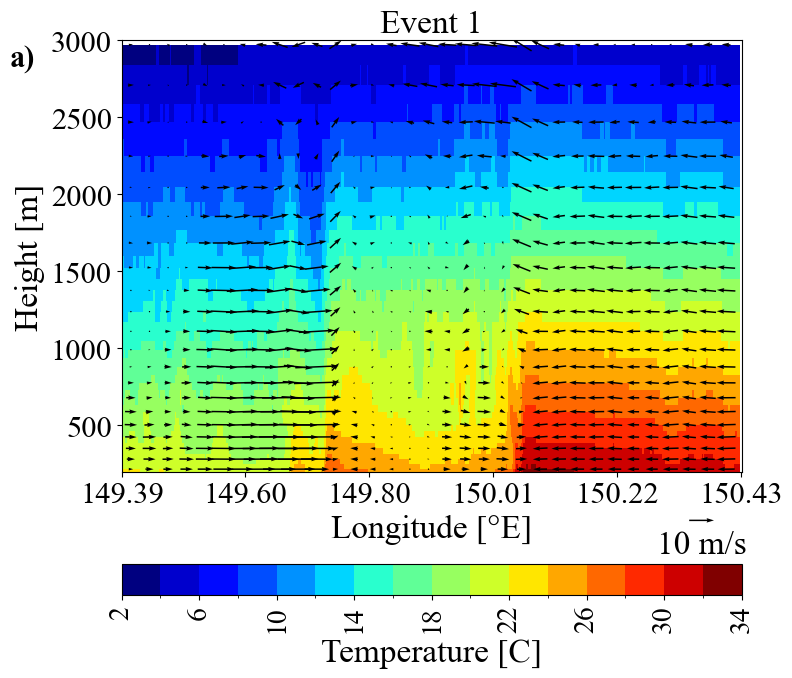

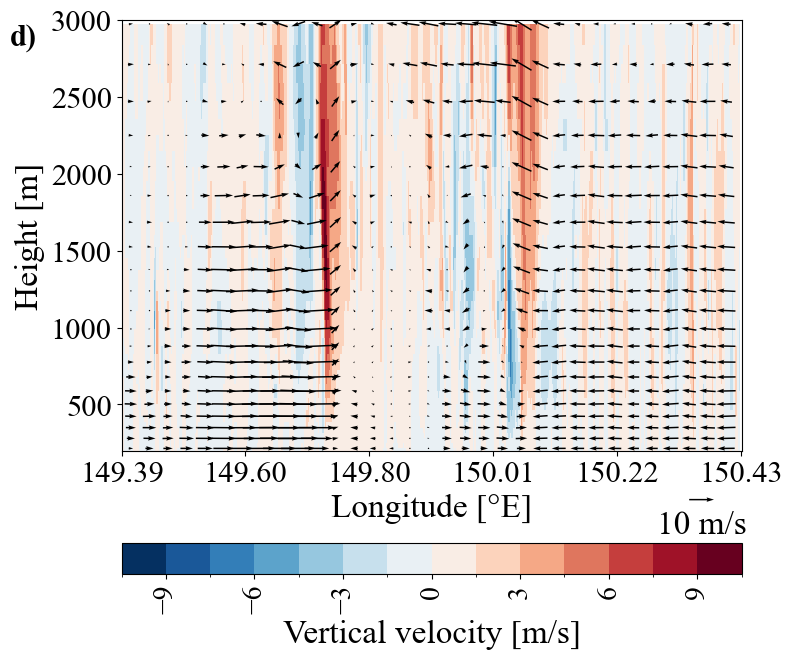

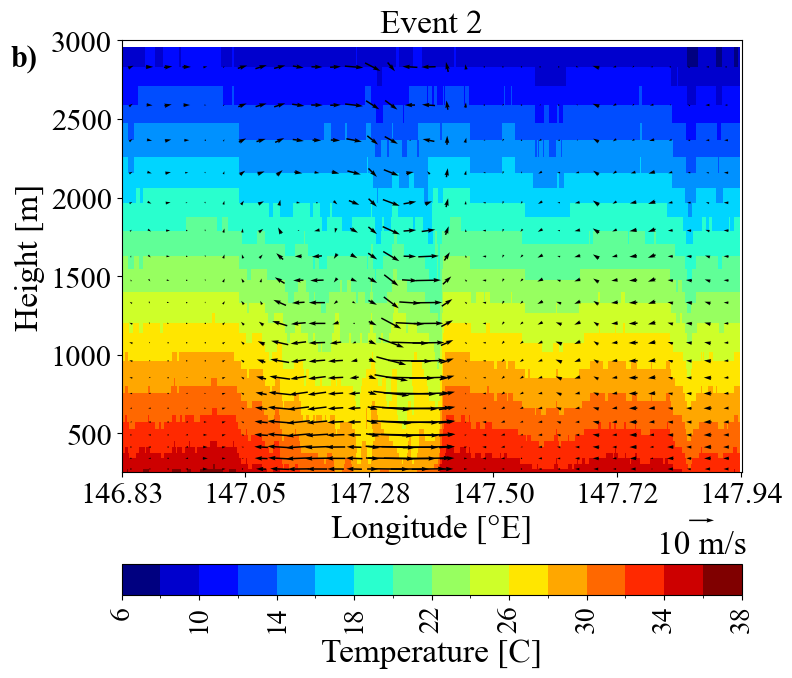

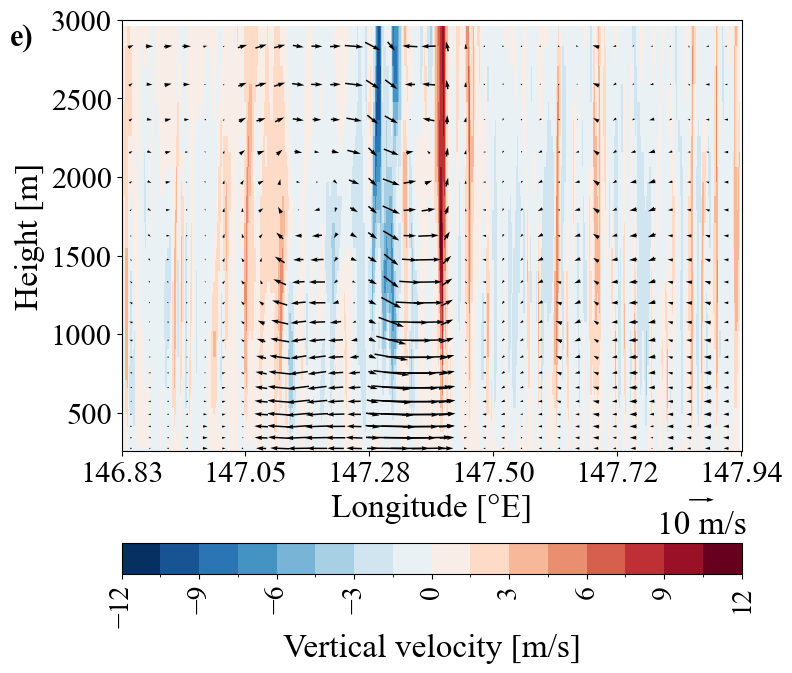

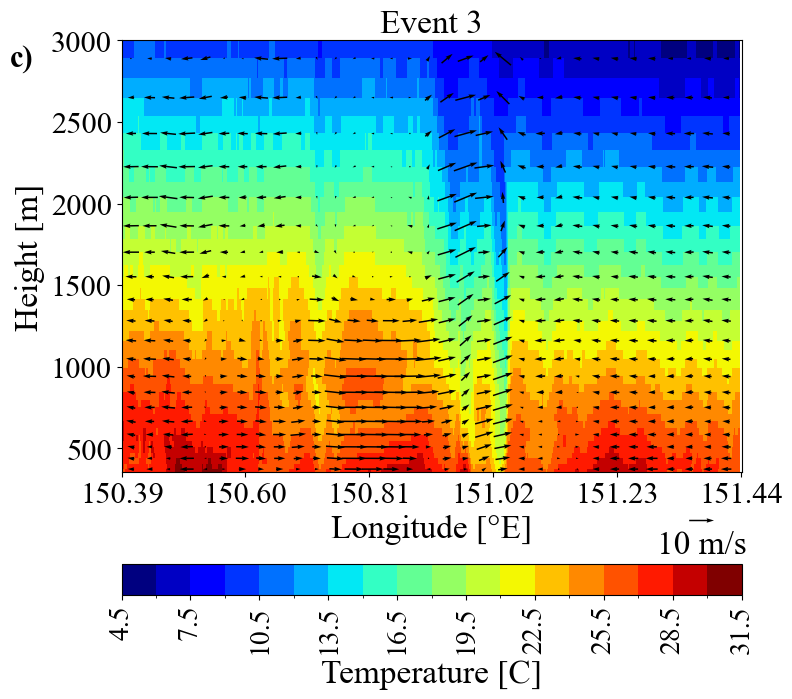

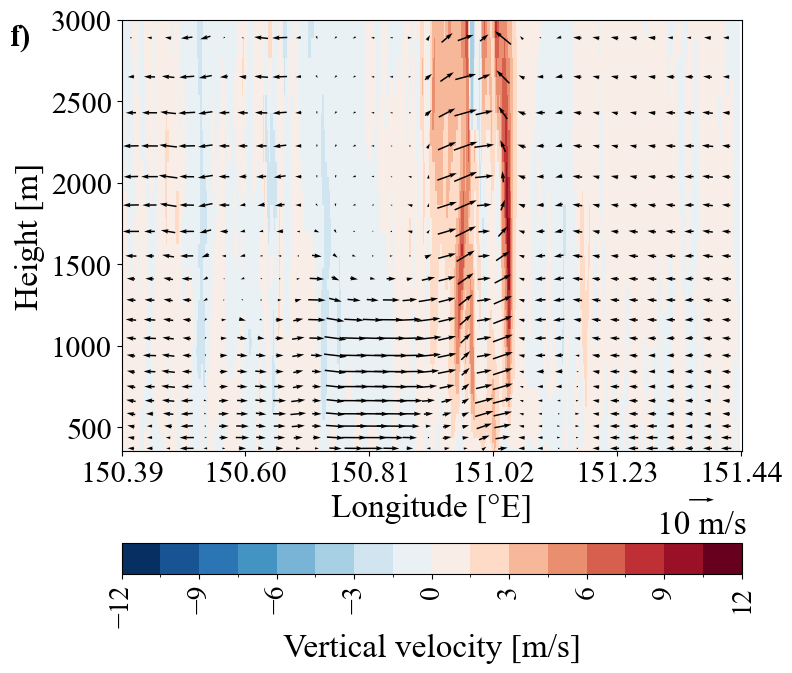

In [24]:
m_h = 3000. # Maximum height in meters
for case in cases:
    # Temperature
    plot_cross_section_one(max_height = m_h, case = case, var_ = "tk", label_var = "Temperature [C]", idx = 30, cmap_ = "jet", n_levels = 20,
                           buffer = 0)
    # Vertical velocity
    plot_cross_section_one(max_height = m_h, case = case, var_ = "wa", label_var = "Vertical velocity [m/s]", idx = 30, cmap_ = "RdBu_r", n_levels = 19, 
                           buffer = 0)#, lims = [-8., 8.])


## Figure 4: Hovmoller

In [12]:
def compute_transect_all_times_z( wrf_all, case, var_, buffer=10, npts=500):
    """
    Returns DataArray with dims:
    (Time, z, transect)
    """

    da = wrf_all[case][var_]

    da = da.chunk({
    "Time": 2,          # or small (2–6)
    "z": 15,            # depends on vertical resolution
    "south_north": -1,  # full dimension
    "west_east": -1,    # full dimension
        })
    
    if var_ == "tk":
        da = da - 273.15

    # Transect definition
    west_east = np.linspace(0, 500, npts)
    south_north = np.linspace(0, 500, npts)

    if buffer > 0:
        offsets = np.arange(-buffer, buffer + 1)
        samples = []

        for dx in offsets:
            for dy in offsets:
                da_i = da.interp(
                    west_east=xr.DataArray(west_east + dx, dims="transect"),
                    south_north=xr.DataArray(south_north + dy, dims="transect"),
                )
                samples.append(da_i)

        da_xs = xr.concat(samples, dim="buffer").mean("buffer")

    else:
        da_xs = da.interp(
            west_east=xr.DataArray(west_east, dims="transect"),
            south_north=xr.DataArray(south_north, dims="transect"),
        )

    # Assign height in vertical coord
    da_xs = da_xs.assign_coords(z=("z", hgt_c[case]))
    
    return da_xs


In [ ]:
# WA
hov_all = {}
var_ = "wa"
buffer = 5
for case in cases:
    da_xs = compute_transect_all_times_z(wrf_all, case, var_, buffer)
    hov_all[case] = da_xs
hov_np_list = [hov_all[c].mean("z").chunk({"Time": -1, "transect": -1}).compute() for c in cases]

In [ ]:
fs = 20
plt.rcParams.update({
    "font.size": fs,            # Controls most text: tick labels, axis labels, legend, etc.
    "axes.titlesize": fs,       # Title size for subplots
    "axes.labelsize": fs,       # Axis label size
    "xtick.labelsize": fs,      # X tick label size
    "ytick.labelsize": fs,      # Y tick label size
    "legend.fontsize": fs-2,      # Legend font size
    "figure.titlesize": fs-2,     # Figure-wide title size (if you use `fig.suptitle`),
     "font.family": "Times New Roman",
})

# Compute common color limits
vmax = max(abs(hov).max() for hov in hov_np_list)
vmin = -vmax

levels = np.linspace(-vmax, vmax, 20)
levels = np.unique(np.round(levels).astype(int))  # integers, unique ensures 0 is included

# BoundaryNorm for discrete colors
norm = BoundaryNorm(levels, ncolors=plt.cm.RdBu_r.N, clip=True)

# Create a colormap normalization based on levels
norm = BoundaryNorm(levels, ncolors=plt.cm.RdBu_r.N, clip=True)

# Plot all 3 cases with shared colorbar
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(7,10), sharex=False, sharey=True)
for ax, case, hov in zip(axes, cases, hov_np_list):
    im = ax.imshow(hov.T, origin="lower", cmap="RdBu_r", norm = norm, aspect="auto")
    ax.set_ylabel("Time [minutes]")
    ax.set_title(name_cases[case])

    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # Set ticks
    lon_array = lons_all[case]    
    nx = len(lon_array)
    # choose tick locations in index space
    xticks = np.linspace(0, nx - 1, 4, dtype=int)
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{lon_array[i]:.2f}" for i in xticks])  
    
fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.05, pad=0.2, label="Vertical velocity [m/s]")
axes[-1].set_xlabel("Longitude [°E]")
fig.subplots_adjust(bottom=0.24, top=0.95, hspace=0.35)
plt.savefig(f"{path_fig}/Figure4.png", dpi=500, bbox_inches="tight")
plt.show()

## Figure 5: Composite w'dev

In [ ]:
def crsection(x, y, U, V, xmin=None, xmax=None, ymin=None, ymax=None,
              xlabel=None, ylabel=None, centered_circle=None,
              title=None, speed_max=None, streamlines_color='grey'):
    """Draw streamlines with linewidth proportional to speed."""
    speed = np.sqrt(U**2 + V**2)
    if speed_max is None:
        speed_max = speed.max()
    lw = 5*speed/speed_max
    plt.streamplot(x, y, U, V, linewidth=lw, color=streamlines_color)

    if xlabel is not None:
        plt.xlabel(xlabel, fontsize=18)
    if ylabel is not None:
        plt.ylabel(ylabel, fontsize=18)
    if xmin is not None and xmax is not None:
        plt.xlim(xmin, xmax)
    if ymin is not None and ymax is not None:
        plt.ylim(ymin, ymax)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)

    if centered_circle is not None:
        ax = plt.gca()
        circle = Circle((0, 0), centered_circle, facecolor='none',
                        edgecolor='k', linewidth=3, zorder=1)
        ax.add_artist(circle)
    if title is not None:
        plt.title(title, fontsize=20)


def plot_field_streamlines_single(ax, x_coor, y_coor, z_coor, field,
                                  U=None, V=None, W=None,
                                  vmin=None, vmax=None,
                                  xmin=None, xmax=None, ymin=None, ymax=None,
                                  centered_circle=None, zero_contour=False,
                                  xlabel='X (R)', ylabel='Y (R)', zlabel='Z (R)',
                                  cblabel=None, title=None, scale=1., symmetric=True,
                                  ticks_fmt='%.1f', axis='xz', x_contour=0, cmap="jet", set_xlabel = True, set_ylabel = True, speed_max = None):
    """
    Plot a single plane (xy, xz, or yz) on a given matplotlib Axes ax.
    """

    # Scale field if needed
    if scale != 1.:
        field = field * scale

    if vmax is None and vmin is None:
        vmax = np.nanmax(field)
        vmin = np.nanmin(field)
    elif vmax is not None and vmin is None:
        vmin = -vmax

    # Compute cell edges for pcolormesh
    def cell_edges(arr):
        edges = np.zeros(len(arr)+1)
        edges[:-1] = arr - 0.5*(arr[1]-arr[0])
        edges[-1] = -edges[0]
        return edges

    x2 = cell_edges(x_coor)
    y2 = cell_edges(y_coor)
    z2 = cell_edges(z_coor)
    
    data = np.ma.masked_array(field, mask=np.isnan(field))
    if speed_max is None:
        speed_max = np.amax(np.sqrt(U**2 + V**2 + W**2))
    #print (speed_max)
    # --------------------
    # Determine center index
    # --------------------
    if axis == 'xy':
        centre = np.where(np.abs(z_coor) < 1e-10)[0][0]
        X, Y = np.meshgrid(x2, y2)
        U_slice = U[:, :, centre].T
        V_slice = V[:, :, centre].T
        data_slice = data[:, :, centre].T
        x_plot, y_plot = x_coor, y_coor
        xlabel_use, ylabel_use = xlabel, ylabel
    elif axis == 'xz':
        centre = np.where(np.abs(y_coor) < 1e-10)[0][0]
        X, Y = np.meshgrid(x2, z2)
        U_slice = U[:, centre, :].T
        V_slice = W[:, centre, :].T
        data_slice = data[:, centre, :].T
        x_plot, y_plot = x_coor, z_coor
        xlabel_use, ylabel_use = xlabel, zlabel
    elif axis == 'yz':
        centre = np.where(np.abs(x_coor) < 1e-10)[0][0]
        X, Y = np.meshgrid(y2, z2)
        U_slice = V[centre, :, :].T
        V_slice = W[centre, :, :].T
        data_slice = data[centre, :, :].T
        x_plot, y_plot = y_coor, z_coor
        xlabel_use, ylabel_use = ylabel, zlabel
    else:
        raise ValueError("axis must be 'xy', 'xz', or 'yz'")

    # --------------------
    # Plot streamlines
    # --------------------
    speed = np.sqrt(U_slice**2 + V_slice**2)
    lw = 3*speed/speed_max
    ax.streamplot(x_plot, y_plot, U_slice, V_slice, linewidth=lw, color='grey')

    # --------------------
    # Plot pcolormesh
    # --------------------
    pcm = ax.pcolormesh(X, Y, data_slice, cmap=cmap, vmin=vmin, vmax=vmax,
                        edgecolors='None', zorder=0)

    # --------------------
    # Contours
    # --------------------
    if zero_contour:
        ax.contour(x_plot, y_plot, data_slice, levels=[0],
                   colors='k', linestyles='dashed', zorder=2)
    if x_contour != 0:
        ax.contour(x_plot, y_plot, data_slice, levels=[x_contour],
                   colors='k', linestyles='dashed', zorder=2)

    # --------------------
    # Labels, limits, ticks
    # --------------------
    if set_xlabel:
        ax.set_xlabel(xlabel_use)
    if set_ylabel:
        ax.set_ylabel(ylabel_use)
    if xmin is not None and xmax is not None:
        ax.set_xlim(xmin, xmax)
    if ymin is not None and ymax is not None:
        ax.set_ylim(ymin, ymax)
    ax.tick_params(axis='both')

    if centered_circle is not None:
        circle = Circle((0, 0), centered_circle, facecolor='none',
                        edgecolor='k', linewidth=3, zorder=1)
        ax.add_artist(circle)

    if title is not None:
        ax.set_title(title, loc = "center")#, fontweight = "bold")

    return pcm


In [ ]:
# W prime
fs = 18
plt.rcParams.update({
    "font.size": fs,            # Controls most text: tick labels, axis labels, legend, etc.
    "axes.titlesize": fs-3,       # Title size for subplots
    "axes.labelsize": fs,       # Axis label size
    "xtick.labelsize": fs,      # X tick label size
    "ytick.labelsize": fs,      # Y tick label size
    "legend.fontsize": fs,      # Legend font size
    "figure.titlesize": fs,     # Figure-wide title size (if you use `fig.suptitle`),
     "font.family": "Times New Roman",
})

downdrafts = [False, True]  # Updrafts (False), Downdrafts (True)
plt_range = 2.3 # Used in the calculation!

# Create 3 rows × 2 columns grid
fig = plt.figure(figsize=(9, 6))
gs = gridspec.GridSpec(nrows=2, ncols=3, figure=fig, hspace=0.25, wspace=0.2)

# Colorbar axes on the right (vertical)
cbar_width = 0.03
cbar_up = fig.add_axes([0.92, 0.55, cbar_width, 0.35])   # Updrafts colorbar (top)
cbar_dd = fig.add_axes([0.92, 0.1, cbar_width, 0.35])    # Downdrafts colorbar (bottom)

# Compute global max velocity (before the loop)
speed_max_global = 0
w_max_global_ud = 0
w_max_global_dd = 0

for col_idx, case in enumerate(cases):
    for row_idx, downdraft in enumerate(downdrafts):
        (
            x_centre, y_centre, z_centre,wmax_c, W_c, time_c, R_c, z_centre_c,mass_c, path_case, N_t, t_range, R_mean, W_mean, R_std, R_10, R_90, W_std, W_10, W_90,
            acc_mean, Fres_mean, Fnh_mean, buoy_mean, acc_10, acc_90,
            Fres_10, Fres_90, Fnh_10, Fnh_90, buoy_10, buoy_90,
            t_range2, net_entr_term_mean, net_entr_term_std,
            Z, R_avg, W_avg, net_entr_avg, Z2, net_entr_l, net_entr_r,
            acc_avg, Fnh_avg, Fres_avg, buoy_avg, Fentr_avg,
            ix_left, ix_right, bins_x, weights_x,
            iz_up, iz_low, bins_z, weights_z,
            acc_c, Fres_c, buoy_c, fnh_c, fmix_c, r_c, r_c_mean, r_c_std,
            acc_c_mean, Fres_c_mean, buoy_c_mean, fnh_c_mean, fmix_c_mean,
            acc_c_std, Fres_c_std, buoy_c_std, fnh_c_std, fmix_c_std,
            N_avg, lifetime_avg, wmax_avg, massflux_avg,
            x_new, y_new, z_new, w_dev_grossmean, u_dev_grossmean, v_dev_grossmean,rh_grossmean, qvapor_grossmean, qrain_grossmean, qcloud_grossmean, qicesnow_grossmean, qghail_grossmean, buoy_mean_t, detrainment_grossmean, entrainment_grossmean, latheat_grossmean, qghail_c, qcloud_c, qicesnow_c, qrain_c,
        ) = data_all_[f"{case}_{dom}_{'dd' if downdraft else 'ud'}"]
        speed_max_global = max(speed_max_global, np.amax(np.sqrt(u_dev_grossmean**2 + v_dev_grossmean**2 + w_dev_grossmean**2)))
        if downdraft:
            w_max_global_dd     = max(w_max_global_dd, np.amax(w_dev_grossmean))
        else:
            w_max_global_ud     = max(w_max_global_ud, np.amax(w_dev_grossmean))

                               
# Loop over cases and downdrafts
for col_idx, case in enumerate(cases):
    for row_idx, downdraft in enumerate(downdrafts):
        ax = fig.add_subplot(gs[row_idx, col_idx])

        # Extract data
        (
            x_centre, y_centre, z_centre,wmax_c, W_c, time_c, R_c, z_centre_c,mass_c, path_case, N_t, t_range, R_mean, W_mean, R_std, R_10, R_90, W_std, W_10, W_90,
            acc_mean, Fres_mean, Fnh_mean, buoy_mean, acc_10, acc_90,
            Fres_10, Fres_90, Fnh_10, Fnh_90, buoy_10, buoy_90,
            t_range2, net_entr_term_mean, net_entr_term_std,
            Z, R_avg, W_avg, net_entr_avg, Z2, net_entr_l, net_entr_r,
            acc_avg, Fnh_avg, Fres_avg, buoy_avg, Fentr_avg,
            ix_left, ix_right, bins_x, weights_x,
            iz_up, iz_low, bins_z, weights_z,
            acc_c, Fres_c, buoy_c, fnh_c, fmix_c, r_c, r_c_mean, r_c_std,
            acc_c_mean, Fres_c_mean, buoy_c_mean, fnh_c_mean, fmix_c_mean,
            acc_c_std, Fres_c_std, buoy_c_std, fnh_c_std, fmix_c_std,
            N_avg, lifetime_avg, wmax_avg, massflux_avg,
            x_new, y_new, z_new, w_dev_grossmean, u_dev_grossmean, v_dev_grossmean, rh_grossmean, qvapor_grossmean, qrain_grossmean, qcloud_grossmean, qicesnow_grossmean, qghail_grossmean, buoy_mean_t, detrainment_grossmean, entrainment_grossmean, latheat_grossmean, qghail_c, qcloud_c, qicesnow_c, qrain_c,
        ) = data_all_[f"{case}_{dom}_{'dd' if downdraft else 'ud'}"]

        set_xlabel = True if row_idx == 1 else False
        set_ylabel = True if col_idx == 0 else False

        wmax = w_max_global_dd if downdraft else w_max_global_ud

        title_ = f"{'Down-thermals' if downdraft else 'Up-thermals'}: {name_cases[case]}" if col_idx == 0 else f"{name_cases[case]}"
        # Plot streamlines in this subplot
        plot_field_streamlines_single(
            ax, x_new, y_new, z_new, w_dev_grossmean,
            U=u_dev_grossmean, V=v_dev_grossmean, W=w_dev_grossmean,
            axis='xz', xmin=-plt_range, xmax=plt_range, ymin=-plt_range, ymax=plt_range,
            centered_circle=1.0, zero_contour=True, 
            cmap='PiYG' if downdraft else 'PiYG_r',
            title=title_,
            vmin=-wmax, vmax=wmax, set_xlabel = set_xlabel, set_ylabel = set_ylabel, speed_max = speed_max_global
            
        )

        if col_idx == 0:
                ax.text(
            -0.28, 1.1, "a)" if row_idx == 0 else "b)",
            transform=ax.transAxes,
            fontsize=16, fontweight="bold",
            va="top", ha="left"
        )

        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

        #ax.tick_params(axis="both", labelbottom=False, labelleft=False)
        #ax.grid(True)

        if col_idx != 0:
            ax.tick_params(axis="y", labelleft=False)
        if row_idx != 1:
            ax.tick_params(axis="x", labelbottom=False)
                    

# Add colorbars for each column
wmax = w_max_global_dd if downdraft else w_max_global_ud
norm_up = plt.cm.ScalarMappable(cmap='PiYG_r', norm=plt.Normalize(vmin=-w_max_global_ud, vmax=w_max_global_ud))
norm_dd = plt.cm.ScalarMappable(cmap='PiYG', norm=plt.Normalize(vmin=-w_max_global_dd, vmax=w_max_global_dd))

for downdraft in downdrafts:
    wmax = w_max_global_dd if downdraft else w_max_global_ud
    step = 1.5
    max_tick = np.ceil(wmax / step) * step   # round up
    ticks = np.arange(-max_tick, max_tick + step, step)
    if downdraft:
        plt.colorbar(norm_up, cax=cbar_up, orientation='vertical', label="$w$' [m/s]", ticks = ticks)
    else:
        plt.colorbar(norm_dd, cax=cbar_dd, orientation='vertical', label="$w$' [m/s]", ticks = ticks)

plt.savefig(f"{path_fig}/Figure5.png", dpi=500, bbox_inches="tight")
plt.show()


## Figure 6: QRAIN and QCLOUD

In [ ]:
# QCLOUD

fs = 18
plt.rcParams.update({
    "font.size": fs,            # Controls most text: tick labels, axis labels, legend, etc.
    "axes.titlesize": fs-3,       # Title size for subplots
    "axes.labelsize": fs,       # Axis label size
    "xtick.labelsize": fs,      # X tick label size
    "ytick.labelsize": fs,      # Y tick label size
    "legend.fontsize": fs,      # Legend font size
    "figure.titlesize": fs,     # Figure-wide title size (if you use `fig.suptitle`),
     "font.family": "Times New Roman",
})

downdrafts = [False, True]  # Updrafts (False), Downdrafts (True)
cmap_ = "jet" 

plt_range = 2.3 # Used in the calculation!

# Create 3 rows × 2 columns grid
fig = plt.figure(figsize=(9, 6))
gs = gridspec.GridSpec(nrows=2, ncols=3, figure=fig, hspace=0.25, wspace=0.2)

# Colorbar axes on the right (vertical)
cbar_width = 0.03
#cbar_up = fig.add_axes([0.92, 0.55, cbar_width, 0.35])   # Updrafts colorbar (top)
#cbar_dd = fig.add_axes([0.92, 0.1, cbar_width, 0.35])    # Downdrafts colorbar (bottom)
cbar_ax = fig.add_axes([0.92, 0.15, 0.03, 0.7])

# Compute global max velocity (before the loop)
speed_max_global = 0
w_max_global_ud_ = 0
w_max_global_dd_ = 0

for col_idx, case in enumerate(cases):
    for row_idx, downdraft in enumerate(downdrafts):
        (
            x_centre, y_centre, z_centre,wmax_c, W_c, time_c, R_c, z_centre_c,mass_c, path_case, N_t, t_range, R_mean, W_mean, R_std, R_10, R_90, W_std, W_10, W_90,
            acc_mean, Fres_mean, Fnh_mean, buoy_mean, acc_10, acc_90,
            Fres_10, Fres_90, Fnh_10, Fnh_90, buoy_10, buoy_90,
            t_range2, net_entr_term_mean, net_entr_term_std,
            Z, R_avg, W_avg, net_entr_avg, Z2, net_entr_l, net_entr_r,
            acc_avg, Fnh_avg, Fres_avg, buoy_avg, Fentr_avg,
            ix_left, ix_right, bins_x, weights_x,
            iz_up, iz_low, bins_z, weights_z,
            acc_c, Fres_c, buoy_c, fnh_c, fmix_c, r_c, r_c_mean, r_c_std,
            acc_c_mean, Fres_c_mean, buoy_c_mean, fnh_c_mean, fmix_c_mean,
            acc_c_std, Fres_c_std, buoy_c_std, fnh_c_std, fmix_c_std,
            N_avg, lifetime_avg, wmax_avg, massflux_avg,
            x_new, y_new, z_new, w_dev_grossmean, u_dev_grossmean, v_dev_grossmean,rh_grossmean, qvapor_grossmean, qrain_grossmean, qcloud_grossmean, qicesnow_grossmean, qghail_grossmean, buoy_mean_t, detrainment_grossmean, entrainment_grossmean, latheat_grossmean, qghail_c, qcloud_c, qicesnow_c, qrain_c,
        ) = data_all_[f"{case}_{dom}_{'dd' if downdraft else 'ud'}"]
        speed_max_global = max(speed_max_global, np.amax(np.sqrt(u_dev_grossmean**2 + v_dev_grossmean**2 + w_dev_grossmean**2)))
        if downdraft:
            w_max_global_dd_     = max(w_max_global_dd_, np.amax(qcloud_grossmean*1000.))
        else:
            w_max_global_ud_     = max(w_max_global_ud_, np.amax(qcloud_grossmean*1000.))

w_max_global_dd = max(w_max_global_dd_, w_max_global_ud_)
w_max_global_ud = max(w_max_global_dd_, w_max_global_ud_)
#print (speed_max_global, w_max_global_ud, w_max_global_dd)

    
# Loop over cases and downdrafts
for col_idx, case in enumerate(cases):
    for row_idx, downdraft in enumerate(downdrafts):
        ax = fig.add_subplot(gs[row_idx, col_idx])

        # Extract data
        (
            x_centre, y_centre, z_centre,wmax_c, W_c, time_c, R_c, z_centre_c,mass_c, path_case, N_t, t_range, R_mean, W_mean, R_std, R_10, R_90, W_std, W_10, W_90,
            acc_mean, Fres_mean, Fnh_mean, buoy_mean, acc_10, acc_90,
            Fres_10, Fres_90, Fnh_10, Fnh_90, buoy_10, buoy_90,
            t_range2, net_entr_term_mean, net_entr_term_std,
            Z, R_avg, W_avg, net_entr_avg, Z2, net_entr_l, net_entr_r,
            acc_avg, Fnh_avg, Fres_avg, buoy_avg, Fentr_avg,
            ix_left, ix_right, bins_x, weights_x,
            iz_up, iz_low, bins_z, weights_z,
            acc_c, Fres_c, buoy_c, fnh_c, fmix_c, r_c, r_c_mean, r_c_std,
            acc_c_mean, Fres_c_mean, buoy_c_mean, fnh_c_mean, fmix_c_mean,
            acc_c_std, Fres_c_std, buoy_c_std, fnh_c_std, fmix_c_std,
            N_avg, lifetime_avg, wmax_avg, massflux_avg,
            x_new, y_new, z_new, w_dev_grossmean, u_dev_grossmean, v_dev_grossmean, rh_grossmean, qvapor_grossmean, qrain_grossmean, qcloud_grossmean, qicesnow_grossmean, qghail_grossmean, buoy_mean_t, detrainment_grossmean, entrainment_grossmean, latheat_grossmean, qghail_c, qcloud_c, qicesnow_c, qrain_c,
        ) = data_all_[f"{case}_{dom}_{'dd' if downdraft else 'ud'}"]

        set_xlabel = True if row_idx == 1 else False
        set_ylabel = True if col_idx == 0 else False

        #print (w_max_global_dd, w_max_global_ud)
        wmax = w_max_global_dd if downdraft else w_max_global_ud

        title_ = f"{'Down-thermals' if downdraft else 'Up-thermals'}: {name_cases[case]}" if col_idx == 0 else f"{name_cases[case]}"

        # Plot streamlines in this subplot
        plot_field_streamlines_single(
            ax, x_new, y_new, z_new, qcloud_grossmean*1000.,
            U=u_dev_grossmean, V=v_dev_grossmean, W=w_dev_grossmean,
            axis='xz', xmin=-plt_range, xmax=plt_range, ymin=-plt_range, ymax=plt_range,
            centered_circle=1.0, zero_contour=True, 
            cmap=cmap_,
            title=title_,
            vmin=0, vmax=wmax, set_xlabel = set_xlabel, set_ylabel = set_ylabel, speed_max = speed_max_global
            
        )
        
        if col_idx == 0:
                ax.text(
            -0.28, 1.1, "a)" if row_idx == 0 else "b)",
            transform=ax.transAxes,
            fontsize=16, fontweight="bold",
            va="top", ha="left"
        )

        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

        #ax.tick_params(axis="both", labelbottom=False, labelleft=False)
        #ax.grid(True)

        if col_idx != 0:
            ax.tick_params(axis="y", labelleft=False)
        
        #if row_idx != 1:
        ax.tick_params(axis="x", labelbottom=False)
        ax.set_xlabel("")

# Add colorbars for each column
assert (w_max_global_dd == w_max_global_ud)
wmax_global = w_max_global_dd 

norm = plt.cm.ScalarMappable(
    cmap=cmap_,
    norm=plt.Normalize(vmin=0, vmax=wmax_global)
)
norm.set_array([])  # required for older Matplotlib

step = 0.5
ticks = np.arange(0, wmax_global + step, step)

plt.colorbar(
    norm,
    cax=cbar_ax,
    orientation='vertical',
    label="Cloud water [g/kg]",
    ticks=ticks
)
plt.savefig(f"{path_fig}/Figure6_1.png", dpi=500, bbox_inches="tight")
plt.show()


In [ ]:
# QRAIN

fs = 18
plt.rcParams.update({
    "font.size": fs,            # Controls most text: tick labels, axis labels, legend, etc.
    "axes.titlesize": fs-3,       # Title size for subplots
    "axes.labelsize": fs,       # Axis label size
    "xtick.labelsize": fs,      # X tick label size
    "ytick.labelsize": fs,      # Y tick label size
    "legend.fontsize": fs,      # Legend font size
    "figure.titlesize": fs,     # Figure-wide title size (if you use `fig.suptitle`),
     "font.family": "Times New Roman",
})

downdrafts = [False, True]  # Updrafts (False), Downdrafts (True)
plt_range = 2.3 # Used in the calculation!

# Create 3 rows × 2 columns grid
fig = plt.figure(figsize=(9, 6))
gs = gridspec.GridSpec(nrows=2, ncols=3, figure=fig, hspace=0.25, wspace=0.2)

# Colorbar axes on the right (vertical)
cbar_width = 0.03
cbar_ax = fig.add_axes([0.92, 0.15, 0.03, 0.7])

# Compute global max velocity (before the loop)
speed_max_global = 0
w_max_global_ud_ = 0
w_max_global_dd_ = 0

for col_idx, case in enumerate(cases):
    for row_idx, downdraft in enumerate(downdrafts):
        (
            x_centre, y_centre, z_centre,wmax_c, W_c, time_c, R_c, z_centre_c,mass_c, path_case, N_t, t_range, R_mean, W_mean, R_std, R_10, R_90, W_std, W_10, W_90,
            acc_mean, Fres_mean, Fnh_mean, buoy_mean, acc_10, acc_90,
            Fres_10, Fres_90, Fnh_10, Fnh_90, buoy_10, buoy_90,
            t_range2, net_entr_term_mean, net_entr_term_std,
            Z, R_avg, W_avg, net_entr_avg, Z2, net_entr_l, net_entr_r,
            acc_avg, Fnh_avg, Fres_avg, buoy_avg, Fentr_avg,
            ix_left, ix_right, bins_x, weights_x,
            iz_up, iz_low, bins_z, weights_z,
            acc_c, Fres_c, buoy_c, fnh_c, fmix_c, r_c, r_c_mean, r_c_std,
            acc_c_mean, Fres_c_mean, buoy_c_mean, fnh_c_mean, fmix_c_mean,
            acc_c_std, Fres_c_std, buoy_c_std, fnh_c_std, fmix_c_std,
            N_avg, lifetime_avg, wmax_avg, massflux_avg,
            x_new, y_new, z_new, w_dev_grossmean, u_dev_grossmean, v_dev_grossmean,rh_grossmean, qvapor_grossmean, qrain_grossmean, qcloud_grossmean, qicesnow_grossmean, qghail_grossmean, buoy_mean_t, detrainment_grossmean, entrainment_grossmean, latheat_grossmean, qghail_c, qcloud_c, qicesnow_c, qrain_c,
        ) = data_all_[f"{case}_{dom}_{'dd' if downdraft else 'ud'}"]
        speed_max_global = max(speed_max_global, np.amax(np.sqrt(u_dev_grossmean**2 + v_dev_grossmean**2 + w_dev_grossmean**2)))
        if downdraft:
            w_max_global_dd_     = max(w_max_global_dd_, np.amax(qrain_grossmean*1000.))
        else:
            w_max_global_ud_     = max(w_max_global_ud_, np.amax(qrain_grossmean*1000.))

w_max_global_dd = max(w_max_global_dd_, w_max_global_ud_)
w_max_global_ud = max(w_max_global_dd_, w_max_global_ud_)
    
# Loop over cases and downdrafts
for col_idx, case in enumerate(cases):
    for row_idx, downdraft in enumerate(downdrafts):
        ax = fig.add_subplot(gs[row_idx, col_idx])

        # Extract data
        (
            x_centre, y_centre, z_centre,wmax_c, W_c, time_c, R_c, z_centre_c,mass_c, path_case, N_t, t_range, R_mean, W_mean, R_std, R_10, R_90, W_std, W_10, W_90,
            acc_mean, Fres_mean, Fnh_mean, buoy_mean, acc_10, acc_90,
            Fres_10, Fres_90, Fnh_10, Fnh_90, buoy_10, buoy_90,
            t_range2, net_entr_term_mean, net_entr_term_std,
            Z, R_avg, W_avg, net_entr_avg, Z2, net_entr_l, net_entr_r,
            acc_avg, Fnh_avg, Fres_avg, buoy_avg, Fentr_avg,
            ix_left, ix_right, bins_x, weights_x,
            iz_up, iz_low, bins_z, weights_z,
            acc_c, Fres_c, buoy_c, fnh_c, fmix_c, r_c, r_c_mean, r_c_std,
            acc_c_mean, Fres_c_mean, buoy_c_mean, fnh_c_mean, fmix_c_mean,
            acc_c_std, Fres_c_std, buoy_c_std, fnh_c_std, fmix_c_std,
            N_avg, lifetime_avg, wmax_avg, massflux_avg,
            x_new, y_new, z_new, w_dev_grossmean, u_dev_grossmean, v_dev_grossmean, rh_grossmean, qvapor_grossmean, qrain_grossmean, qcloud_grossmean, qicesnow_grossmean, qghail_grossmean, buoy_mean_t, detrainment_grossmean, entrainment_grossmean, latheat_grossmean, qghail_c, qcloud_c, qicesnow_c, qrain_c,
        ) = data_all_[f"{case}_{dom}_{'dd' if downdraft else 'ud'}"]

        set_xlabel = True if row_idx == 1 else False
        set_ylabel = True if col_idx == 0 else False

        wmax = w_max_global_dd if downdraft else w_max_global_ud

        title_ = f"{'Down-thermals' if downdraft else 'Up-thermals'}: {name_cases[case]}" if col_idx == 0 else f"{name_cases[case]}"

        # Plot streamlines in this subplot
        plot_field_streamlines_single(
            ax, x_new, y_new, z_new, qrain_grossmean*1000.,
            U=u_dev_grossmean, V=v_dev_grossmean, W=w_dev_grossmean,
            axis='xz', xmin=-plt_range, xmax=plt_range, ymin=-plt_range, ymax=plt_range,
            centered_circle=1.0, zero_contour=True, 
            cmap=cmap_,
            title=title_,
            vmin=0, vmax=wmax, set_xlabel = set_xlabel, set_ylabel = set_ylabel, speed_max = speed_max_global
            
        )

        if col_idx == 0:
                ax.text(
            -0.28, 1.1, "c)" if row_idx == 0 else "d)",
            transform=ax.transAxes,
            fontsize=16, fontweight="bold",
            va="top", ha="left"
        )

        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        
        if col_idx != 0:
            ax.tick_params(axis="y", labelleft=False)
        if row_idx != 1:
            ax.tick_params(axis="x", labelbottom=False)

# Add colorbars for each column
assert (w_max_global_dd == w_max_global_ud)
wmax_global = w_max_global_dd 

norm = plt.cm.ScalarMappable(
    cmap=cmap_,
    norm=plt.Normalize(vmin=0, vmax=wmax_global)
)
norm.set_array([])  # required for older Matplotlib

step = 0.25
ticks = np.arange(0, wmax_global + step, step)

plt.colorbar(
    norm,
    cax=cbar_ax,
    orientation='vertical',
    label="Rain water [g/kg]",
    ticks=ticks
)
plt.savefig(f"{path_fig}/Figure6_2.png", dpi=500, bbox_inches="tight")
plt.show()


## Figure 7: Histograms and boxplots

In [ ]:
def plot_density_axis(
    ax,
    *series,
    labels,
    nbins=15,
    title="",
    x_label="X Axis",
    density=False,
    prec=2,
    colors=["blue", "orange", "green"],
    lims_val=None,
    xticks = True,
    yticks = True
):
    """
    Function to plot the density (relative frequency) for multiple time series.

    Parameters:
        *series: multiple time series (arrays) to plot
        labels: list of labels for each time series
        nbins: number of bins for the histograms
        lims_val: tuple (min_val, max_val), optional
    """

    # Determine min and max values
    if lims_val is not None:
        min_val, max_val = lims_val
    else:
        min_val = np.min([np.min(s) for s in series])
        max_val = np.max([np.max(s) for s in series])

    # Set the bin edges
    bins = np.linspace(min_val, max_val, nbins)

    # Loop through each series and plot
    for i, s in enumerate(series):
        h, b = np.histogram(s, bins=bins)

        if density:
            h_rel = 100 * h / float(np.sum(h))
        else:
            h_rel = h

        xbins = b[:-1] + (b[1:] - b[:-1]) / 2.0

        mean = np.round(np.mean(s), prec)
        a = ax.plot(xbins, h_rel, lw=4.5, c=colors[i])

        ax.axvline(
            x=np.mean(s),
            ls="--",
            c=a[0].get_color(),
            lw=2.0
        )

    # Labels and styling
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Frequency [%]" if density else "Count")
    ax.legend(loc=0, frameon=False)
    ax.grid(axis="y", ls="--")

    ax.set_ylim(0,77)

    if not xticks:
        ax.set_xticks([])

def plot_combined_characteristics(
    cases,
    dom,
    name_cases,
    lt_mean,
    r_mean,
    w_mean,
    z_init,
    dist,
    plot_density_axis,
    density=True,
    nbins=10,
):

    fs = 28
    plt.rcParams.update({
        "font.size": fs,            # Controls most text: tick labels, axis labels, legend, etc.
        "axes.titlesize": fs,       # Title size for subplots
        "axes.labelsize": fs,       # Axis label size
        "xtick.labelsize": fs,      # X tick label size
        "ytick.labelsize": fs,      # Y tick label size
        "legend.fontsize": fs,      # Legend font size
        "figure.titlesize": fs,     # Figure-wide title size (if you use `fig.suptitle`),
         "font.family": "Times New Roman",
    })

    cases_names = [name_cases[c] for c in cases]
    labels_2 = ["Down", "Up"]
    colors_ = ["dodgerblue", "coral"]

    # ---- Figure layout: 4 rows x 5 columns ----
    fig, axes = plt.subplots(
        4, 4, figsize=(20, 16)
    )

    # =========================
    # ROW 0 → BAR PLOTS (Fig 1)
    # =========================
    char_info = [
        ("Lifetime [min]", lt_mean, False),
        ("Radius [m]", r_mean, False),
        ("|W mean| [m/s]", w_mean, True),
        ("Z initial [m]", z_init, False),
    ]

    for col_i, (label, data_dict, abs_dd) in enumerate(char_info):
        ax = axes[0, col_i]

        means_dd, means_ud = [], []

        for case in cases:
            dd_vals = data_dict[f"{case}_{dom}_dd"]
            ud_vals = data_dict[f"{case}_{dom}_ud"]

            dd_mean = np.nanmean(dd_vals)
            ud_mean = np.nanmean(ud_vals)

            if abs_dd:
                dd_mean = abs(dd_mean)

            means_dd.append(abs(dd_mean))
            means_ud.append(ud_mean)

        x = np.arange(len(cases))
        width = 0.35

        ax.bar(x - width/2, means_dd, width, label="Down", color="dodgerblue")
        ax.bar(x + width/2, means_ud, width, label="Up", color="coral")

        ax.set_title(label, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(cases_names)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

        if col_i == 0:
            ax.set_ylabel("Mean value")
            ax.legend(loc = 3)
            ax.text(
            -0.3, 1.0, "a)",
            transform=ax.transAxes,
            fontsize=26, fontweight="bold",
            va="top", ha="left"
        )

        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.tick_params(axis="y", labelsize = 24)
        for lbl in ax.get_yticklabels():
            lbl.set_va("center")
            
    # =================================
    # ROWS 1–3 → DENSITY PLOTS (Fig 2)
    # =================================
    data_maps = [
        ("Lifetime [min]", lt_mean),
        ("Radius [m]", r_mean),
        ("|W mean| [m/s]", w_mean),
        ("Z initial [m]", z_init),
    ]

    for row_i, case in enumerate(cases):
        for col_i, (xlabel, data_dict) in enumerate(data_maps):

            ax = axes[row_i + 1, col_i]

            dd = data_dict[f"{case}_{dom}_dd"]
            ud = data_dict[f"{case}_{dom}_ud"]

            # Minimum and maximum among all cases
            vmin = np.min([np.min(abs(v)) for v in data_dict.values()])
            vmax = np.max([np.max(abs(v)) for v in data_dict.values()])

            if "W mean" in xlabel or "distance" in xlabel:
                dd = abs(dd)

            if (np.array([len(dd), len(ud)]) >= 30).all():
                plot_density_axis(
                    ax, dd, ud,
                    labels=labels_2,
                    x_label=xlabel,
                    density=density,
                    nbins=nbins,
                    colors=colors_,
                    lims_val = [vmin, vmax],
                    xticks = True if row_i == 2 else False,
                    yticks = True if col_i == 0 else False
                )
            else:
                plot_density_axis(
                    ax, dd,
                    labels=["Down"],
                    x_label=xlabel,
                    density=density,
                    nbins=nbins,
                    colors=colors_,
                    lims_val = [vmin, vmax],
                    xticks = True if row_i == 2 else False,
                    yticks = True if col_i == 0 else False
                )

            labels_ = ["b)", "c)", "d)"]
            if col_i == 0:
                ax.set_ylabel(f"{name_cases[case]} \n Frequency [%]")#, fontweight="bold")
                ax.text(
                    -0.3, 1.0, labels_[row_i],
                    transform=ax.transAxes,
                    fontsize=26, fontweight="bold",
                    va="top", ha="left"
                )
            else:
                ax.set_ylabel("")

            if row_i < len(cases) - 1:
                ax.set_xlabel("")

            
            ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
            ax.xaxis.set_major_locator(MaxNLocator(nbins=4))

            #ax.tick_params(axis="both", labelbottom=False, labelleft=False)
            #ax.grid(True)

            if col_i != 0:
                ax.tick_params(axis="y", labelleft=False)
            if row_i != 2:
                ax.tick_params(axis="x", labelbottom=False)
            ax.grid(axis = "both", ls = "--")

    # ---- Spacing ----
    fig.subplots_adjust(
        left=0.05,
        right=0.98,
        top=0.95,
        bottom=0.06,
        wspace=0.17,
        hspace=0.18,
    )

    plt.savefig(f"{path_fig}/Figure7.png", dpi=500, bbox_inches="tight")
    plt.show()



In [ ]:
# Get quantities for histograms
downdrafts = [False, True]  # Updrafts (False → left), Downdrafts (True → right)

lt_mean   = {} 
r_mean    = {}
w_mean    = {}
wmax_mean = {}
z_init    = {}
z_fin     = {}
dist      = {}
x_init    = {}

for i, downdraft in enumerate(downdrafts):
    
    for j, case in enumerate(cases):

        key = f"{case}_{dom}_{'dd' if downdraft else 'ud'}"
        # Extract data
        (
            x_centre, y_centre, z_centre,wmax_c, W_c, time_c, R_c, z_centre_c,mass_c, path_case, N_t, t_range, R_mean, W_mean, R_std, R_10, R_90, W_std, W_10, W_90,
            acc_mean, Fres_mean, Fnh_mean, buoy_mean, acc_10, acc_90,
            Fres_10, Fres_90, Fnh_10, Fnh_90, buoy_10, buoy_90,
            t_range2, net_entr_term_mean, net_entr_term_std,
            Z, R_avg, W_avg, net_entr_avg, Z2, net_entr_l, net_entr_r,
            acc_avg, Fnh_avg, Fres_avg, buoy_avg, Fentr_avg,
            ix_left, ix_right, bins_x, weights_x,
            iz_up, iz_low, bins_z, weights_z,
            acc_c, Fres_c, buoy_c, fnh_c, fmix_c, r_c, r_c_mean, r_c_std,
            acc_c_mean, Fres_c_mean, buoy_c_mean, fnh_c_mean, fmix_c_mean,
            acc_c_std, Fres_c_std, buoy_c_std, fnh_c_std, fmix_c_std,
            N_avg, lifetime_avg, wmax_avg, massflux_avg,
            x_new, y_new, z_new, w_dev_grossmean, u_dev_grossmean, v_dev_grossmean,
                        rh_grossmean, qvapor_grossmean, qrain_grossmean, qcloud_grossmean, qicesnow_grossmean, qghail_grossmean, buoy_mean_t, detrainment_grossmean, entrainment_grossmean, latheat_grossmean, qghail_c, qcloud_c, qicesnow_c, qrain_c
        ) = data_all_[key]

        # Get quantities for histograms
        wmax_mean[key] = np.nanmean(wmax_c, axis = 1)
        w_mean[key] = np.nanmean(W_c, axis = 1)
        r_mean[key] = np.nanmean(R_c, axis = 1)
        #assert (start_zero == True) # To calculate z init - z fin correctly
        #z_init[key] = z_centre_c[:,0]
        z_init[key] = np.array([z_centre_c[i][~np.isnan(z_centre_c[i])][0] for i in range(len(z_centre_c))])
        z_fin[key]  = np.fliplr(z_centre_c)[np.arange(z_centre_c.shape[0]),np.fliplr(~np.isnan(z_centre_c)).argmax(axis=1)] # Last no-nan
        lt_mean[key] = (~np.isnan(time_c)).sum(axis=1)
        dist[key] = z_fin[key] - z_init[key]

        x_init[key] = x_centre[:,0]

In [ ]:
plot_combined_characteristics(
    cases,
    dom,
    name_cases,
    lt_mean,
    r_mean,
    w_mean,
    z_init,
    dist,
    plot_density_axis,
    density=True,
    nbins=10,
)

## Figure 8: R and W

In [ ]:
def height_profile(
        x, z, legend = None, label=None, fname=None, xmin=None, xmax=None, zero=True,
        zmin=0, zmax=6.0, title=None, xlabel=None, xticks=None,
        range_l=None, range_r=None, clr='grey', filled=False, thin=False,
        ylabel=True, colors=['k','b','g','r'], linestyles=['-','-','-','-'],
        ax=None, lw = 2.0, 
    ):
    """""""""""""""""""""""""""""""""""""""""""""""""""
    Function to plot certain variable against height
    """""""""""""""""""""""""""""""""""""""""""""""""""

    # --- Create axis if not supplied ---
    if ax is None:
        if thin:
            fig = plt.figure(figsize=(3.5,7))
            ax = fig.add_axes([0.1,0.14,0.81,0.76])
        else:
            fig = plt.figure(figsize=(5.5,7))
            ax = fig.add_axes([0.14,0.14,0.81,0.76])

    rc('text', usetex=False)

    # Ensure lists
    if type(x) != list:
        x = [x]
    if type(z) != list:
        z = [z]

    # --- Plot each profile ---
    for i in range(len(x)):
        if label is not None:
            ax.plot(x[i], z[i], label=label[i], color=colors[i],
                    ls=linestyles[i], lw=lw)
        else:
            ax.plot(x[i], z[i], color=colors[i], ls=linestyles[i], lw=lw)

        if range_l is not None and not filled:
            ax.plot(range_l[i], z[i], ls='--', color=colors[i], alpha=0.5)

        if range_r is not None and not filled:
            ax.plot(range_r[i], z[i], ls='--', color=colors[i], alpha=0.5)

        if filled and range_l is not None and range_r is not None:
            ax.fill_betweenx(z[i], range_l[i], range_r[i],
                             alpha=0.3, facecolor=clr)

    # Zero line
    if zero:
        ax.axvline(0, color='grey', ls='--', lw=2)

    # Limits
    if xmin is not None and xmax is not None:
        ax.set_xlim(xmin, xmax)

    ax.set_ylim(zmin, zmax)

    # Legend
    if legend is not None:
        ax.legend(frameon=False)

    # Labels
    if xlabel is not None:
        ax.set_xlabel(xlabel)

    if title is not None:
        ax.set_title(title)#, fontweight = "bold")

    if ylabel:
        ax.set_ylabel('Height (km)')

    ax.tick_params(axis='both', which='major')

    if xticks is not None:
        ax.set_xticks(xticks)

    ax.grid(axis = "y", ls = "--",  c = "grey", which = "both")

    return ax


In [ ]:
fs = 28
plt.rcParams.update({
    "font.size": fs,            # Controls most text: tick labels, axis labels, legend, etc.
    "axes.titlesize": fs,       # Title size for subplots
    "axes.labelsize": fs,       # Axis label size
    "xtick.labelsize": fs,      # X tick label size
    "ytick.labelsize": fs,      # Y tick label size
    "legend.fontsize": fs,      # Legend font size
    "figure.titlesize": fs,     # Figure-wide title size (if you use `fig.suptitle`),
     "font.family": "Times New Roman",
})

# CONFIGURATION
downdrafts = [False, True]
colors_ = ["k", "magenta", "green"]
threshold_len = 4

# FIGURE + GRIDSPEC
fig = plt.figure(figsize=(22, 10))

outer = GridSpec(
    2, 2,
    width_ratios=[1, 1],
    height_ratios=[2, 1],
    wspace=0.2,   
    hspace=0.35
)

gs_left = GridSpecFromSubplotSpec(
    2, 2,
    subplot_spec=outer[:, 0],
    wspace=0.10,
    hspace=0.35,
    height_ratios=[2, 1]  
)

# RIGHT BLOCK (columns 2-3)
gs_right = GridSpecFromSubplotSpec(
    2, 2,
    subplot_spec=outer[:, 1],
    wspace=0.10,
    hspace=0.35,
    height_ratios=[2, 1]  
)

ax_W_prof_ud = fig.add_subplot(gs_left[0, 0])
ax_W_prof_dd = fig.add_subplot(gs_left[0, 1], sharey=ax_W_prof_ud)

ax_W_time_ud = fig.add_subplot(gs_left[1, 0])
ax_W_time_dd = fig.add_subplot(gs_left[1, 1], sharey=ax_W_time_ud)

ax_R_prof_ud = fig.add_subplot(gs_right[0, 0])
ax_R_prof_dd = fig.add_subplot(gs_right[0, 1], sharey=ax_R_prof_ud)

ax_R_time_ud = fig.add_subplot(gs_right[1, 0])
ax_R_time_dd = fig.add_subplot(gs_right[1, 1], sharey=ax_R_time_ud)

# TOP ROW — PROFILES
for i, downdraft in enumerate(downdrafts):
    axW = ax_W_prof_dd if downdraft else ax_W_prof_ud
    axR = ax_R_prof_dd if downdraft else ax_R_prof_ud

    for j, case in enumerate(cases):

        (x_centre, y_centre, z_centre, wmax_c, W_c, time_c, R_c, z_centre_c,
            mass_c, path_case, N_t, t_range, R_mean, W_mean, R_std, R_10, R_90,
            W_std, W_10, W_90, acc_mean, Fres_mean, Fnh_mean, buoy_mean,
            acc_10, acc_90, Fres_10, Fres_90, Fnh_10, Fnh_90,
            buoy_10, buoy_90, t_range2, net_entr_term_mean,
            net_entr_term_std, Z, R_avg, W_avg, net_entr_avg,
            Z2, net_entr_l, net_entr_r, acc_avg, Fnh_avg,
            Fres_avg, buoy_avg, Fentr_avg, ix_left, ix_right,
            bins_x, weights_x, iz_up, iz_low, bins_z,
            weights_z, acc_c, Fres_c, buoy_c, fnh_c, fmix_c,
            r_c, r_c_mean, r_c_std, acc_c_mean, Fres_c_mean,
            buoy_c_mean, fnh_c_mean, fmix_c_mean,
            acc_c_std, Fres_c_std, buoy_c_std,
            fnh_c_std, fmix_c_std, N_avg, lifetime_avg,
            wmax_avg, massflux_avg, x_new, y_new, z_new,
            w_dev_grossmean, u_dev_grossmean, v_dev_grossmean,
            rh_grossmean, qvapor_grossmean, qrain_grossmean,
            qcloud_grossmean, qicesnow_grossmean, qghail_grossmean, buoy_mean_t, detrainment_grossmean, entrainment_grossmean, latheat_grossmean, qghail_c, qcloud_c, qicesnow_c, qrain_c
        ) = data_all_[f"{case}_{dom}_{'dd' if downdraft else 'ud'}"]

        # ---- W profile ----
        height_profile(
            [np.abs(W_avg)],
            [Z / 1e3],
            ax=axW,
            colors=colors_[j],
            linestyles=["-"],
            xlabel="|W| [m s$^{-1}$]",
            ylabel="Height (km)" if not downdraft else None,
            xmin=1.0,
            xmax=6.1,
            zmin=1.0,
            zmax=6.0,
            label=[name_cases[case]],
            legend=None if downdraft else True,
            zero=False, lw = 3.0, 
        )

        # ---- R profile ----
        height_profile(
            [R_avg],
            [Z / 1e3],
            ax=axR,
            colors=colors_[j],
            linestyles=["-"],
            xlabel="R [m]",
            ylabel="Height (km)" if not downdraft else None,
            xmin=500,
            xmax=1200,
            zmin=1.0,
            zmax=6.0,
            label=[name_cases[case]],
            legend=None,
            zero=False,lw = 3.0
        )

    axW.yaxis.set_major_locator(MultipleLocator(1))  # every 1 km
    axW.grid(ls="--", c="grey", axis="y")
    
    axR.yaxis.set_major_locator(MultipleLocator(1))  # every 1 km
    axR.grid(ls="--", c="grey", axis="y")

    axW.set_title("Down-thermals" if downdraft else "Up-thermals")
    axR.set_title("Down-thermals" if downdraft else "Up-thermals")

# BOTTOM ROW — TIME SERIES
for downdraft in downdrafts:
    axW = ax_W_time_dd if downdraft else ax_W_time_ud
    axR = ax_R_time_dd if downdraft else ax_R_time_ud

    for j, case in enumerate(cases):

        (x_centre, y_centre, z_centre, wmax_c, W_c, time_c, R_c, z_centre_c,
            mass_c, path_case, N_t, t_range, R_mean, W_mean, R_std, R_10, R_90,
            W_std, W_10, W_90, acc_mean, Fres_mean, Fnh_mean, buoy_mean,
            acc_10, acc_90, Fres_10, Fres_90, Fnh_10, Fnh_90,
            buoy_10, buoy_90, t_range2, net_entr_term_mean,
            net_entr_term_std, Z, R_avg, W_avg, net_entr_avg,
            Z2, net_entr_l, net_entr_r, acc_avg, Fnh_avg,
            Fres_avg, buoy_avg, Fentr_avg, ix_left, ix_right,
            bins_x, weights_x, iz_up, iz_low, bins_z,
            weights_z, acc_c, Fres_c, buoy_c, fnh_c, fmix_c,
            r_c, r_c_mean, r_c_std, acc_c_mean, Fres_c_mean,
            buoy_c_mean, fnh_c_mean, fmix_c_mean,
            acc_c_std, Fres_c_std, buoy_c_std,
            fnh_c_std, fmix_c_std, N_avg, lifetime_avg,
            wmax_avg, massflux_avg, x_new, y_new, z_new,
            w_dev_grossmean, u_dev_grossmean, v_dev_grossmean,
            rh_grossmean, qvapor_grossmean, qrain_grossmean,
            qcloud_grossmean, qicesnow_grossmean, qghail_grossmean, buoy_mean_t, detrainment_grossmean, entrainment_grossmean, latheat_grossmean, qghail_c, qcloud_c, qicesnow_c, qrain_c
        ) = data_all_[f"{case}_{dom}_{'dd' if downdraft else 'ud'}"]


        len_thermals = (~np.isnan(time_c)).sum(axis=1)
        cond_len = np.where(len_thermals >= threshold_len)[0]

        # ---- |W|(t) ----
        W_mean = np.nanmean(np.abs(W_c[cond_len]), axis=0)
        W_std  = np.nanstd(np.abs(W_c[cond_len]), axis=0)

        axW.plot(t_range, W_mean, lw=2.5, color=colors_[j])
        axW.plot(t_range, W_mean + W_std, "--", color=colors_[j], lw=1.2)
        axW.plot(t_range, W_mean - W_std, "--", color=colors_[j], lw=1.2)

        # ---- R(t) ----
        R_mean = np.nanmean(R_c[cond_len], axis=0)
        R_std  = np.nanstd(R_c[cond_len], axis=0)

        axR.plot(t_range, R_mean, lw=2.5, color=colors_[j])
        axR.plot(t_range, R_mean + R_std, "--", color=colors_[j], lw=1.2)
        axR.plot(t_range, R_mean - R_std, "--", color=colors_[j], lw=1.2)

    axW.axvline(0, ls="--", c="grey")
    axR.axvline(0, ls="--", c="grey")

    xmin = 0 if start_zero else -2
    xmax = 4 if start_zero else 2

    axW.set_xlim(xmin, xmax)
    axR.set_xlim(xmin, xmax)

    axW.xaxis.set_major_locator(MaxNLocator(nbins=4))
    axR.xaxis.set_major_locator(MaxNLocator(nbins=4))

    axW.set_ylim(0, 7)
    axR.set_ylim(0, 1500)

    axW.set_xlabel("Time (min)")
    axR.set_xlabel("Time (min)")

    axW.yaxis.set_major_locator(MaxNLocator(nbins=4))
    axR.yaxis.set_major_locator(MaxNLocator(nbins=4))

    axW.grid(ls="--", c="grey", axis="x")
    axR.grid(ls="--", c="grey", axis="x")


# LABELS
ax_W_time_ud.set_ylabel("|W| [m s$^{-1}$]")
ax_R_time_ud.set_ylabel("R [m]")

# PANEL LETTERS
ax_W_prof_ud.text(-0.18, 1.00, "a)", transform=ax_W_prof_ud.transAxes,
                  fontsize=30, fontweight="bold")
ax_R_prof_ud.text(-0.3, 1.00, "b)", transform=ax_R_prof_ud.transAxes,
                  fontsize=30, fontweight="bold")
ax_W_time_ud.text(-0.18, 1.05, "c)", transform=ax_W_time_ud.transAxes,
                  fontsize=30, fontweight="bold")
ax_R_time_ud.text(-0.3, 1.05, "d)", transform=ax_R_time_ud.transAxes,
                  fontsize=30, fontweight="bold")

# For second and last columns
for ax in [ax_W_prof_dd, ax_W_time_dd, ax_R_prof_dd, ax_R_time_dd]:
    ax.tick_params(axis='y', which='both', left=False, labelleft=False)

plt.savefig(f"{path_fig}/Figure8.png", dpi=500, bbox_inches="tight")
plt.show()


## Figure 9: Profile budget

In [ ]:
# Profile budget
fs = 20
plt.rcParams.update({
    "font.size": fs,            # Controls most text: tick labels, axis labels, legend, etc.
    "axes.titlesize": fs,       # Title size for subplots
    "axes.labelsize": fs,       # Axis label size
    "xtick.labelsize": fs,      # X tick label size
    "ytick.labelsize": fs,      # Y tick label size
    "legend.fontsize": fs,      # Legend font size
    "figure.titlesize": fs,     # Figure-wide title size (if you use `fig.suptitle`),
     "font.family": "Times New Roman",
})

downdrafts = [False, True]
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (12,10))
for i, downdraft in enumerate(downdrafts):
    for j, case in enumerate(cases):
        ax = axes[i, j]   # ← select corresponding axis
        legend = None
        ylabel = "Height" if j == 0 else False
        title = f"{'Down-thermals' if downdraft else 'Up-thermals'} - {name_cases[case]} " if j == 0 else f"{name_cases[case]}"
            
        xlabel='m$\,$s$^{-2}$' if i == 1 else None
        
        # Get data 
        x_centre, y_centre, z_centre, wmax_c, W_c, time_c, R_c, z_centre_c,mass_c, path_case, N_t, t_range, R_mean, W_mean, R_std, R_10, R_90, W_std, W_10, W_90, acc_mean, Fres_mean,Fnh_mean,buoy_mean,acc_10,acc_90, Fres_10, Fres_90,Fnh_10, Fnh_90, buoy_10, buoy_90, t_range2, net_entr_term_mean, net_entr_term_std, Z, R_avg, W_avg, net_entr_avg, Z2, net_entr_l, net_entr_r, acc_avg, Fnh_avg, Fres_avg, buoy_avg, Fentr_avg, ix_left, ix_right, bins_x, weights_x, iz_up, iz_low, bins_z, weights_z, acc_c, Fres_c, buoy_c, fnh_c, fmix_c, r_c, r_c_mean, r_c_std,  acc_c_mean, Fres_c_mean,buoy_c_mean, fnh_c_mean, fmix_c_mean,  acc_c_std, Fres_c_std, buoy_c_std, fnh_c_std, fmix_c_std,  N_avg, lifetime_avg, wmax_avg, massflux_avg,     x_new, y_new, z_new, w_dev_grossmean, u_dev_grossmean, v_dev_grossmean, rh_grossmean, qvapor_grossmean, qrain_grossmean, qcloud_grossmean, qicesnow_grossmean, qghail_grossmean, buoy_mean_t, detrainment_grossmean, entrainment_grossmean, latheat_grossmean, qghail_c, qcloud_c, qicesnow_c, qrain_c = data_all_[f"{case}_{dom}_{'dd' if downdraft else 'ud'}"]
        # Plot
        height_profile( [acc_avg,buoy_avg,Fnh_avg,Fres_avg,Fentr_avg], [Z/1e3,Z/1e3,Z/1e3,Z/1e3, Z/1e3],
                       label=['$dW/dt$','$B$',u'$F_{nh}$',u'$F_{mix}$', u"$F_{entr}$"], xticks=None,
                       fname=None, xlabel = xlabel ,
                       linestyles = ["-"]*5,
                      colors=['k','b','g','r', 'magenta'], zmax=6.0, zmin = 1.0,
                       title = title, legend = legend,
                       ax = ax, 
                       ylabel = ylabel, 
                       xmin = -0.022, xmax = 0.022, lw = 2.0,
                      ) #ALEJANDRA

        if j == 0:
            ax.text(
        -0.18, 1.08, "a)" if i == 0 else "b)",
        transform=ax.transAxes,
        fontsize=20, fontweight="bold",
        va="top", ha="left"
    )

        if j != 0:
            ax.tick_params(axis="y", labelleft=False)
        if i != 1:
            ax.tick_params(axis="x", labelbottom=False)

# Common legend
handles, labels = axes[0,0].get_legend_handles_labels()
fig.subplots_adjust(wspace=0.12, hspace = 0.18)
fig.legend(handles, labels, loc="upper center", ncol=5)
plt.savefig(f"{path_fig}/Figure9.png", dpi=500, bbox_inches="tight")
plt.show()

## Figure 10: Time series budget certain index

In [ ]:
def composite_plot_all_ax(ax, t, t2, series_list, labels, pctl_list=None, 
                          ylabel='Value', colors=['k','b','g','r', 'm'], xmin=None, xmax=None,
                          ymax=None, ymin=None, xtick_dist=2, 
                          zero_x=True, zero_y=True, grid=False, title=None,
                          alpha_band=0.2, xlabel = None):

    """""""""""""""""""""""""""""""""""""""""""""""""""
    Function to plot the time series of the composites
    """""""""""""""""""""""""""""""""""""""""""""""""""
    
    majorLocator = MultipleLocator(xtick_dist)

    if xlabel:
        ax.set_xlabel('Time (min)')
    ax.set_ylabel(ylabel)

    if zero_y:
        ax.axhline(0, color='grey', ls='--', lw=2.5)
    if zero_x:
        ax.axvline(0, color='grey', ls='--', lw=2.5)

    if colors is None:
        colors = ['C0', 'C1', 'C2', 'C3', 'C4']

    for i, y in enumerate(series_list):
        try:
            clr = colors[i % len(colors)]
            ax.plot(t, y, label=labels[i], color=clr, lw=2.5)
            if pctl_list is not None and pctl_list[i] is not None:
                lower, upper = pctl_list[i]
                ax.fill_between(t, lower, upper, color=clr, alpha=alpha_band, lw=0)
        except:  # entrainment with t2
            clr = colors[i % len(colors)]
            ax.plot(t2, y, label=labels[i], color=clr, lw=2.5)
            if pctl_list is not None and pctl_list[i] is not None:
                lower, upper = pctl_list[i]
                ax.fill_between(t2, lower, upper, color=clr, alpha=alpha_band, lw=0)

    if title:
        ax.set_title(title, loc="left")

    if xmin is not None and xmax is not None:
        ax.set_xlim(xmin, xmax)
    if ymin is not None or ymax is not None:
        ax.set_ylim(ymin if ymin is not None else -ymax, ymax)

    ax.xaxis.set_major_locator(majorLocator)
    if grid:
        ax.grid()


In [ ]:
# Get indexes below and after 3000m that meet len condition
indexes_above_3000 = {}
indexes_below_3000 = {}

threshold_len = 4

for key in z_fin.keys():
    
    len_thermals = lt_mean[key]
    cond_len = np.where(len_thermals >= threshold_len)[0]

    above_3000 = np.where(z_fin[key] > 3000)[0]
    below_3000 = np.where(z_fin[key] <= 3000)[0]

    indexes_above_3000[key] = [i for i in above_3000 if i in cond_len ]
    indexes_below_3000[key] = [i for i in below_3000 if i in cond_len ]


In [ ]:
fill_between = False
start_zero = False

fs = 22
plt.rcParams.update({
    "font.size": fs,            # Controls most text: tick labels, axis labels, legend, etc.
    "axes.titlesize": fs,       # Title size for subplots
    "axes.labelsize": fs,       # Axis label size
    "xtick.labelsize": fs,      # X tick label size
    "ytick.labelsize": fs,      # Y tick label size
    "legend.fontsize": fs,      # Legend font size
    "figure.titlesize": fs,     # Figure-wide title size (if you use `fig.suptitle`),
     "font.family": "Times New Roman",
})

fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey=True)

for row_idx, downdraft in enumerate([False,True]):
    
    for col_idx, case in enumerate(cases):

        ax = axes[row_idx, col_idx]

        # -----------------------------
        # Load main data for this case
        # -----------------------------
        (
             x_centre, y_centre, z_centre,wmax_c, W_c, time_c, R_c, z_centre_c,mass_c, path_case, N_t, t_range, R_mean, W_mean, R_std, R_10, R_90, W_std, W_10, W_90,
            acc_mean, Fres_mean, Fnh_mean, buoy_mean, acc_10, acc_90,
            Fres_10, Fres_90, Fnh_10, Fnh_90, buoy_10, buoy_90,
            t_range2, net_entr_term_mean, net_entr_term_std,
            Z, R_avg, W_avg, net_entr_avg, Z2, net_entr_l, net_entr_r,
            acc_avg, Fnh_avg, Fres_avg, buoy_avg, Fentr_avg,
            ix_left, ix_right, bins_x, weights_x,
            iz_up, iz_low, bins_z, weights_z,
            acc_c, Fres_c, buoy_c, fnh_c, fmix_c, r_c, r_c_mean, r_c_std,
            acc_c_mean, Fres_c_mean, buoy_c_mean, fnh_c_mean, fmix_c_mean,
            acc_c_std, Fres_c_std, buoy_c_std, fnh_c_std, fmix_c_std,
            N_avg, lifetime_avg, wmax_avg, massflux_avg,
            x_new, y_new, z_new, w_dev_grossmean, u_dev_grossmean, v_dev_grossmean,
                        rh_grossmean, qvapor_grossmean, qrain_grossmean, qcloud_grossmean, qicesnow_grossmean, qghail_grossmean, buoy_mean_t, detrainment_grossmean, entrainment_grossmean, latheat_grossmean, qghail_c, qcloud_c, qicesnow_c, qrain_c
        ) = data_all_[f"{case}_{dom}_{'dd' if downdraft else 'ud'}"]

        # -----------------------------
        # Select indexes
        # -----------------------------
        key = f"{case}_{dom}_{'dd' if downdraft else 'ud'}"

        index_name = "<= 3000 m" if downdraft else "> 3000 m"
        
        if index_name == "> 3000 m":
            index_filt = indexes_above_3000[key]

        elif index_name == "<= 3000 m":
            index_filt   = indexes_below_3000[key]

        else:
            print  ("Define another index")

        # -----------------------------
        # Compute means + stds
        # -----------------------------
        acc_c_mean_f  = np.nanmean(acc_c[index_filt], axis=0)
        Fres_c_mean_f = np.nanmean(Fres_c[index_filt], axis=0)
        buoy_c_mean_f = np.nanmean(buoy_c[index_filt], axis=0)
        fnh_c_mean_f  = np.nanmean(fnh_c[index_filt], axis=0)
        fmix_c_mean_f = np.nanmean(fmix_c[index_filt], axis=0)

        acc_c_std_f  = np.nanstd(acc_c[index_filt], axis=0)
        Fres_c_std_f = np.nanstd(Fres_c[index_filt], axis=0)
        buoy_c_std_f = np.nanstd(buoy_c[index_filt], axis=0)
        fnh_c_std_f  = np.nanstd(fnh_c[index_filt], axis=0)
        fmix_c_std_f = np.nanstd(fmix_c[index_filt], axis=0)

        # -----------------------------
        # Plot
        # -----------------------------
        composite_plot_all_ax(
            ax=ax,
            t=t_range,
            t2=t_range2,
            series_list=[acc_c_mean_f, buoy_c_mean_f, fnh_c_mean_f, Fres_c_mean_f, fmix_c_mean_f],
            labels =['$dW/dt$','$B$',u'$F_{nh}$',u'$F_{mix}$', u"$F_{entr}$"], 
            ylabel=f"{'Down-thermal' if downdraft else 'Up-thermal'} \n acceleration " + r'[ms$^{-2}$]' if col_idx == 0 else "",
            xlabel="Time [min]" if row_idx == 1 else "",
            xmin=0 if start_zero else -2,
            xmax=4 if start_zero else 2,
            xtick_dist=1,
            zero_x=True, zero_y=True,
            grid=True,
            title=f"{name_cases[case]} [{index_name}] N={len(index_filt)}",
            alpha_band=0.12,
            ymin=-0.02, ymax=0.02
        )

        if col_idx == 0:
            ax.text(
        -0.31, 1.1, "a)" if row_idx == 0 else "b)",
        transform=ax.transAxes,
        fontsize=24, fontweight="bold",
        va="top", ha="left"
    )
        if row_idx != 1:
            ax.tick_params(axis="x", labelbottom=False)

                 

# Common legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.01))

fig.subplots_adjust(
    hspace=0.2, wspace = 0.1  # vertical space between rows
)

plt.savefig(f"{path_fig}/Figure10.png", dpi=500, bbox_inches="tight")
plt.show()
